In [1]:
# We load the competition data

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings("ignore")

/kaggle/input/playground-series-s5e5/sample_submission.csv
/kaggle/input/playground-series-s5e5/train.csv
/kaggle/input/playground-series-s5e5/test.csv


# Packages

In [2]:
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 8.7 MB/s eta 0:00:00


# Libraries

In [3]:
import numpy as np
import pandas as pd
import ydata_profiling as pp
import sweetviz as sv
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    RandomizedSearchCV
)
from sklearn.metrics import (
    r2_score, 
    mean_squared_log_error
)
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Predict Calorie Expenditure

### Playground Series - Season 5, Episode 5

### Your Goal: 

Your goal is to predict how many calories were burned during a workout.

### Evaluation:

The evaluation metric for this competition is Root Mean Squared Logarithmic Error(RMSLE).

### Submission File:

For each id row in the test set, you must predict the continuous target, Calories. The file should contain a header and have the following format:

id,Calories

750000,93.2
750001,27.42
750002,103.8
etc.

### Timeline

Start Date - May 1, 2025

Entry Deadline - Same as the Final Submission Deadline

Team Merger Deadline - Same as the Final Submission Deadline

Final Submission Deadline - May 31, 2025

All deadlines are at 11:59 PM UTC on the corresponding day unless otherwise noted. 

The competition organizers reserve the right to update the contest timeline if they deem it necessary.

# Initial analysis

In [4]:
# We load the data

calories_train = pd.read_csv("/kaggle/input/playground-series-s5e5/train.csv", index_col="id")

In [5]:
calories_train.shape

(750000, 8)

In [6]:
calories_train.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
id,,,,,,,,
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [7]:
calories_train.describe().style.background_gradient(cmap='Greens')

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [8]:
calories_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         750000 non-null  object 
 1   Age         750000 non-null  int64  
 2   Height      750000 non-null  float64
 3   Weight      750000 non-null  float64
 4   Duration    750000 non-null  float64
 5   Heart_Rate  750000 non-null  float64
 6   Body_Temp   750000 non-null  float64
 7   Calories    750000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 51.5+ MB


# EDA

We start by using auto EDA tools, not just to test them, but also to take a different approach to traditional data exploration. Later, if time permits, I will leave a version with a more traditional EDA approach, with some general function to explore each variable and visualize the data with Seaborn, as I have already done in other notebooks.

We will try two alternatives:

- YData Profiling
  
https://docs.profiling.ydata.ai/latest/

https://github.com/ydataai/ydata-profiling

- SweetViz

https://pypi.org/project/sweetviz/

https://github.com/fbdesignpro/sweetviz

## YData Profiling

In [9]:
# We pass the data to the profiler

profile_calories = pp.ProfileReport(calories_train, title="Calories Profiling Report")

# Get the full profile

profile_calories

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:03<00:00,  2.13it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## SweetViz

Uncomment the comparison line of code to compare the train and test datasets with the tool. I usually start by analyzing and processing the train data and then focus on testing, but if you want to do that first, I'll leave the line of code. Don't forget to comment the analyze function line and load the test data.

                                             |          | [  0%]   00:00 -> (? left)


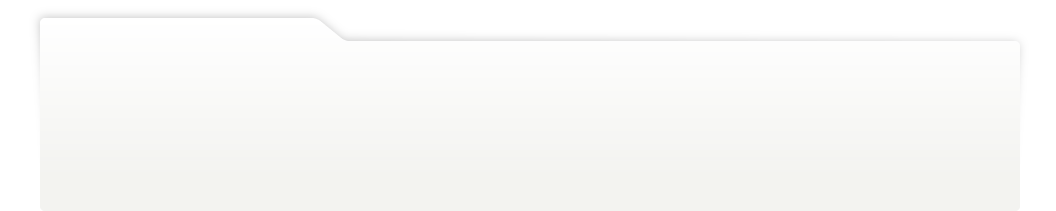
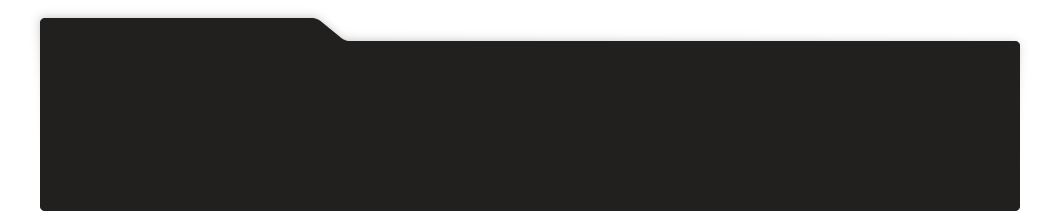
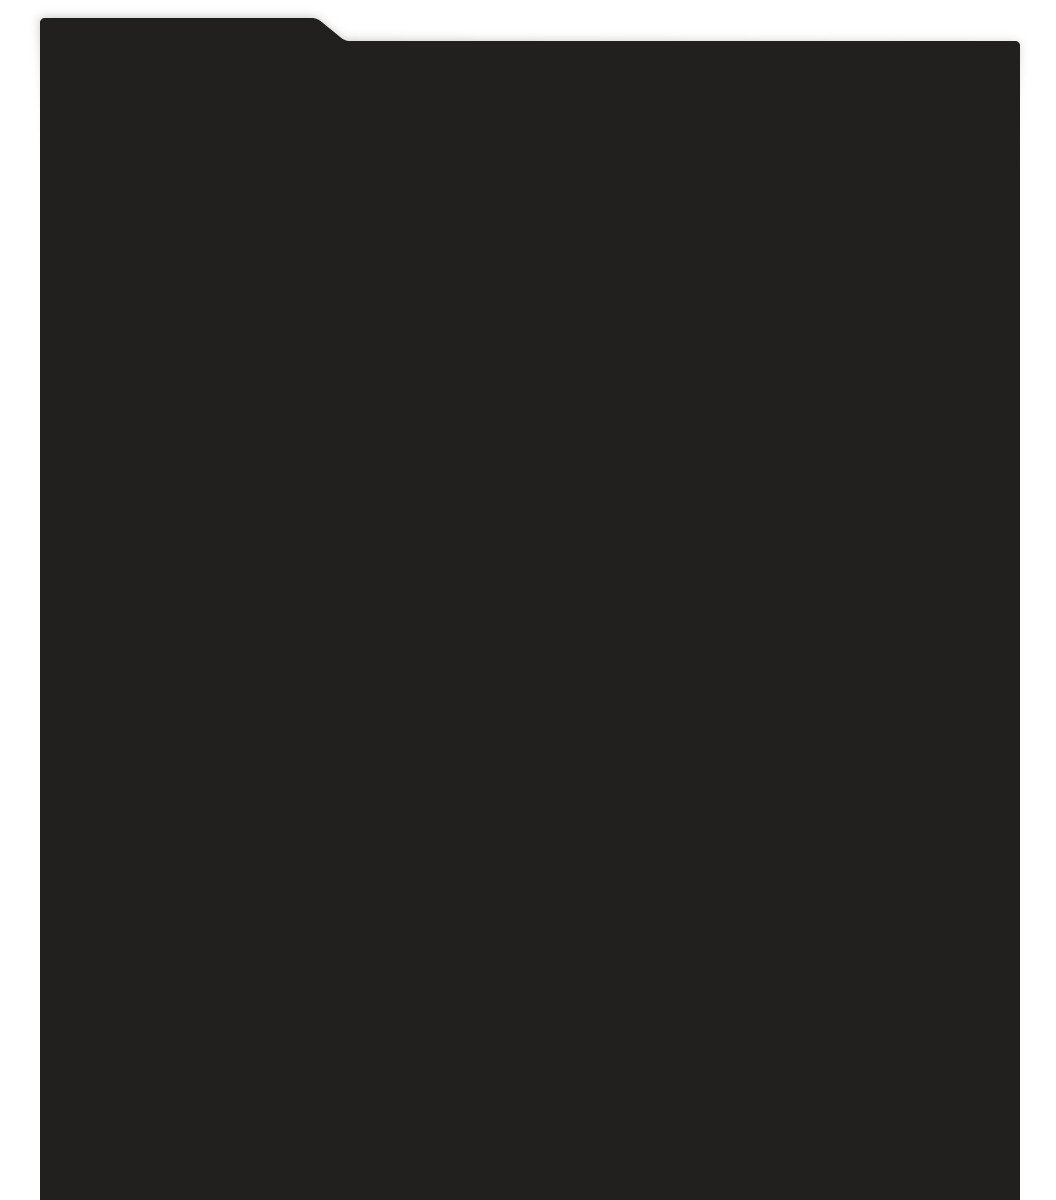
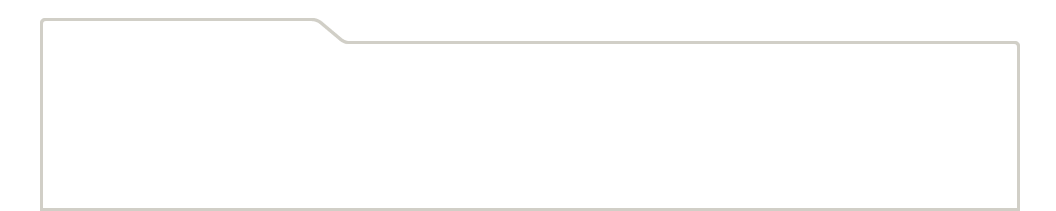
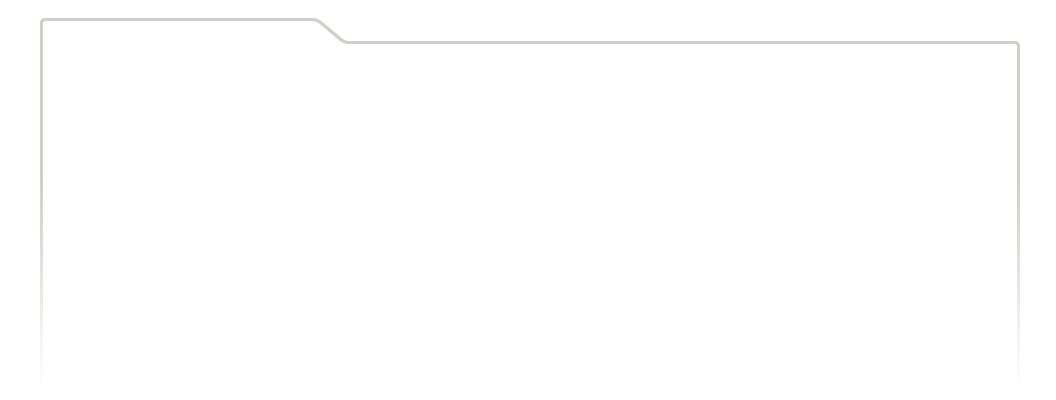
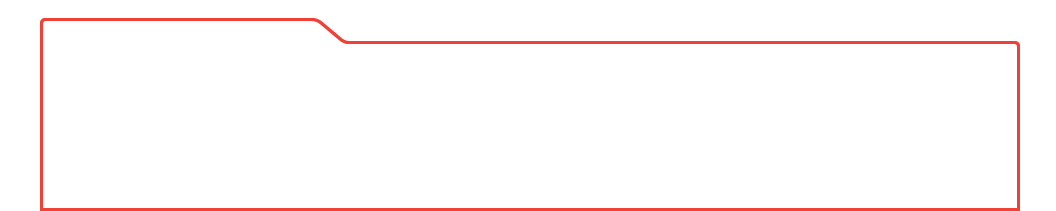
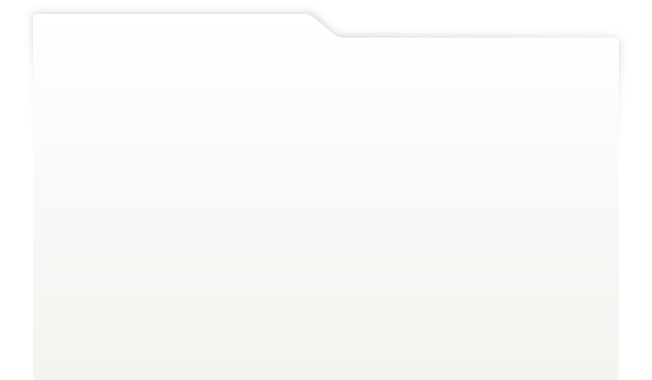
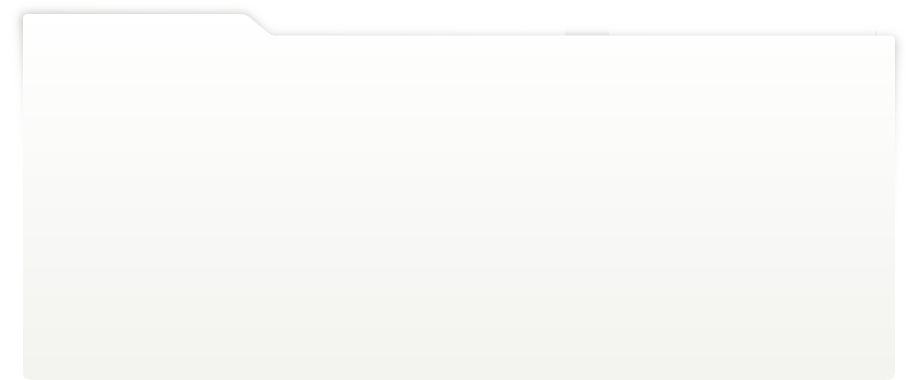
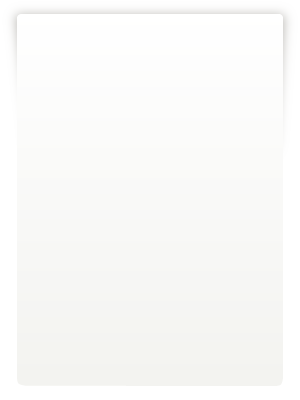
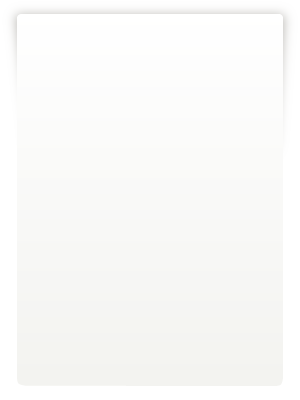
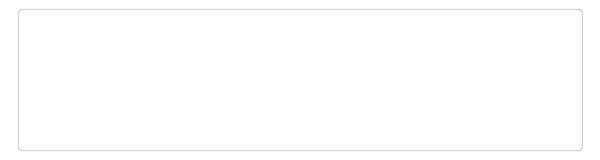
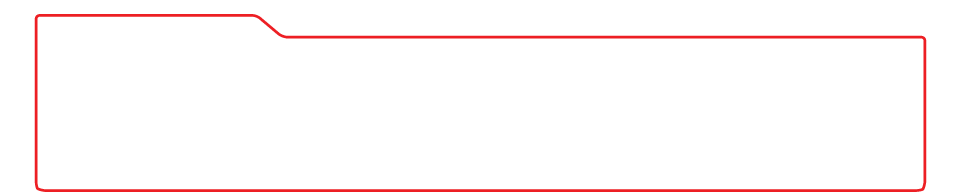
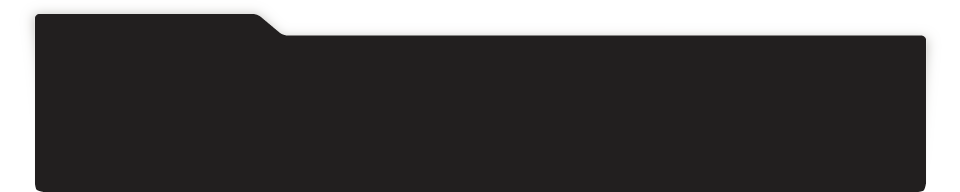
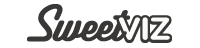
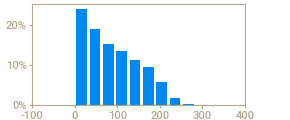
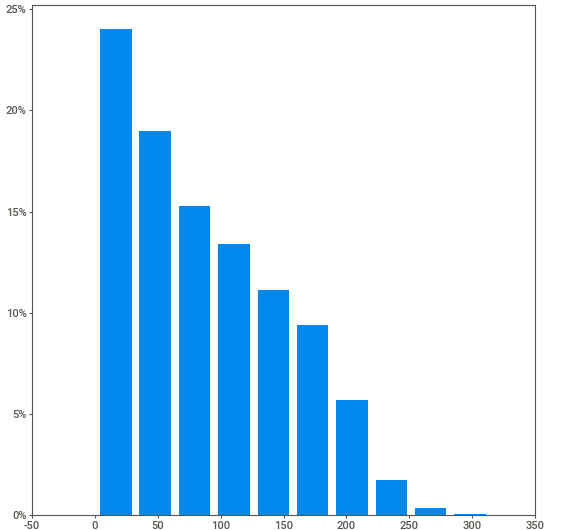
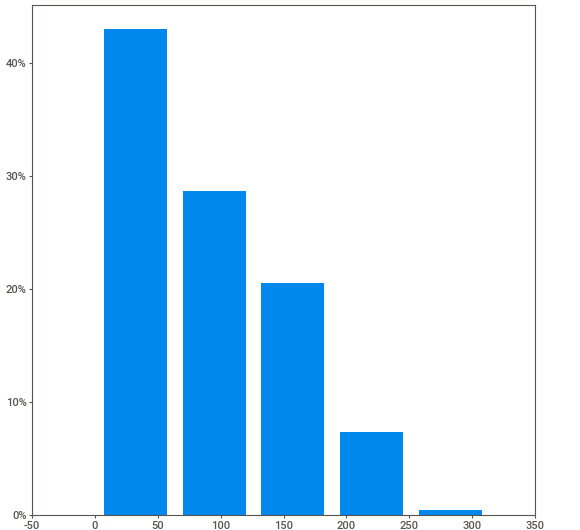
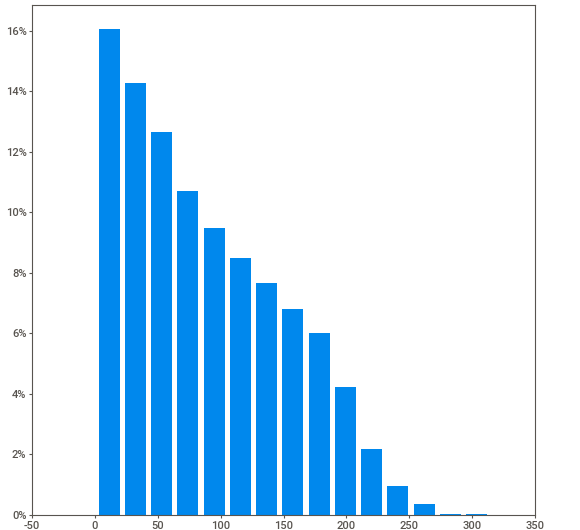
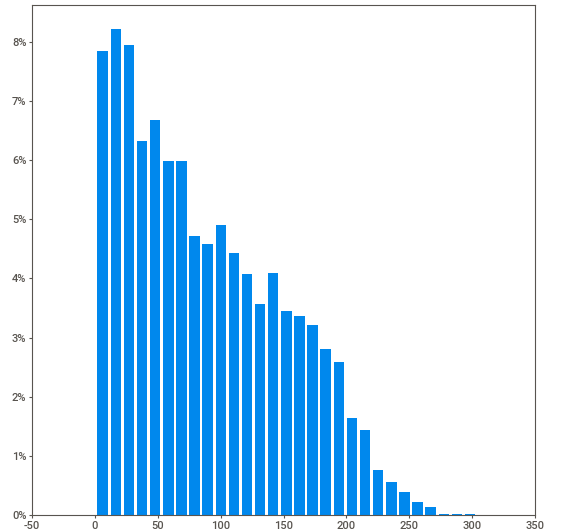
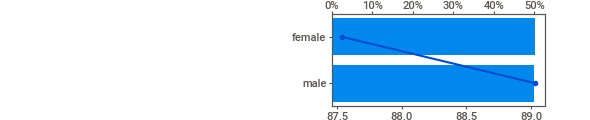
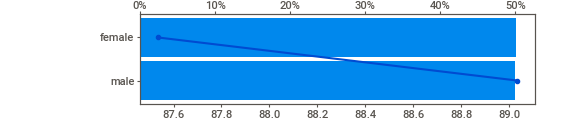
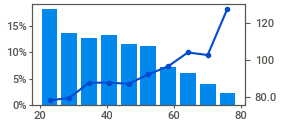
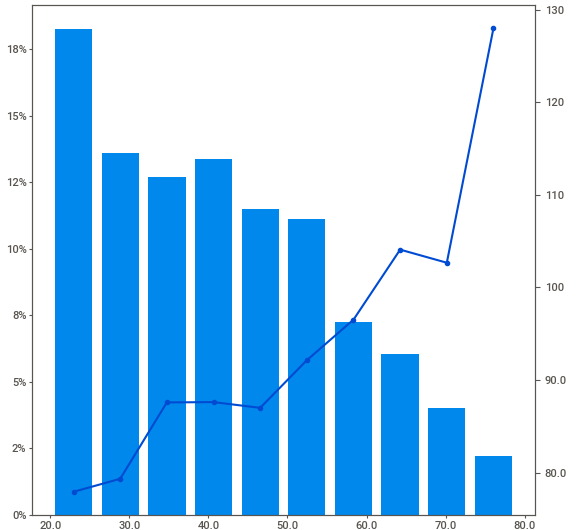
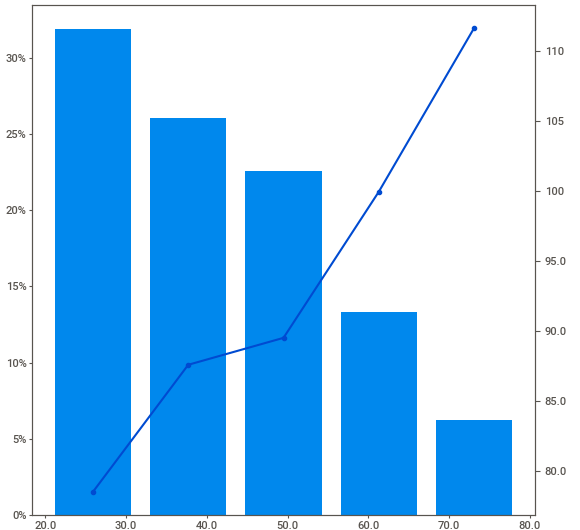
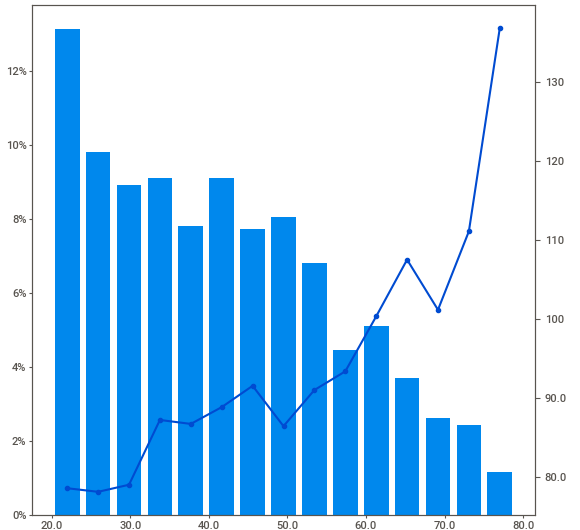
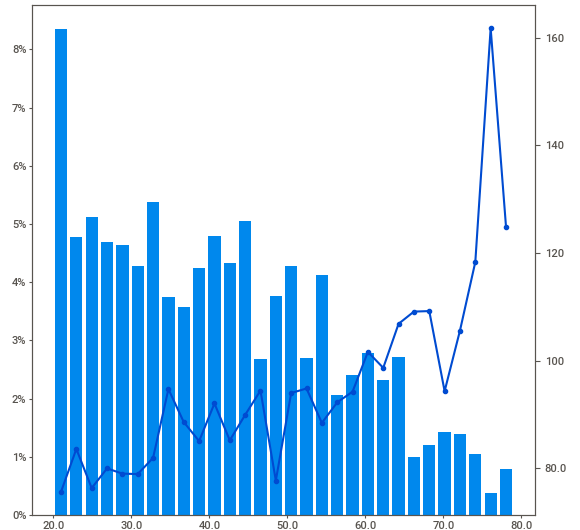
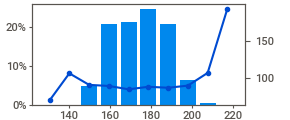
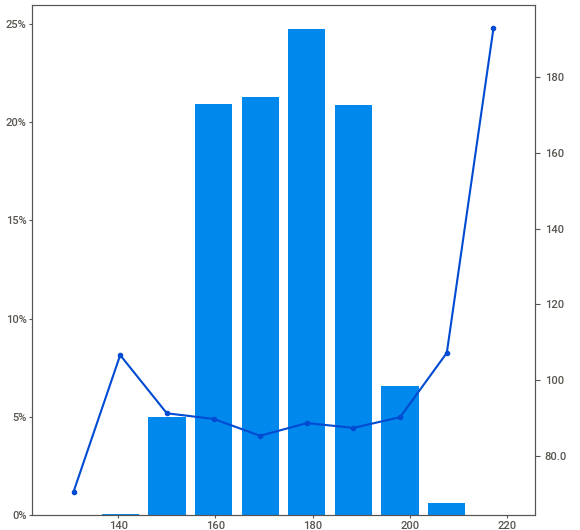
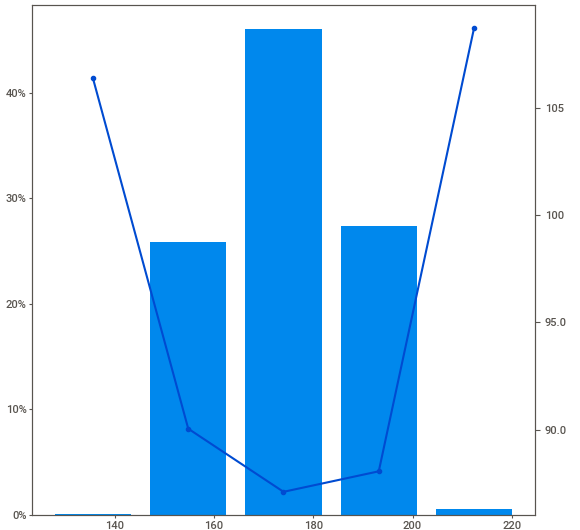
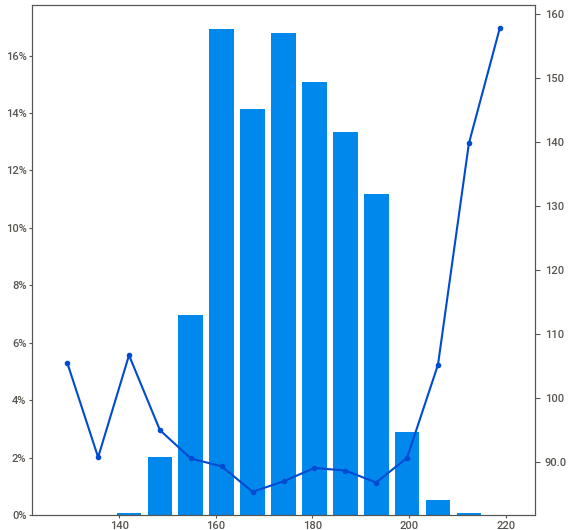
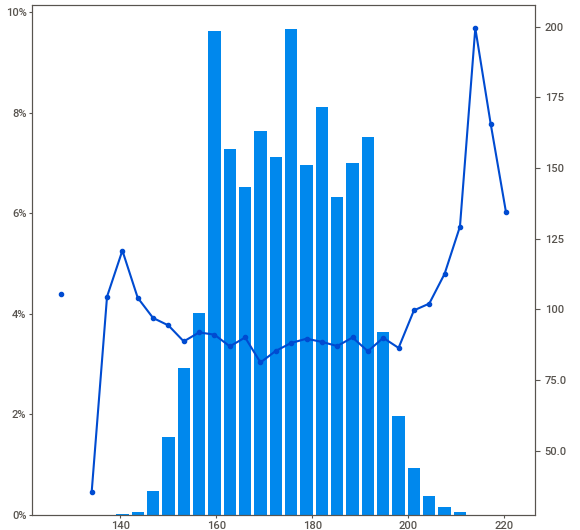
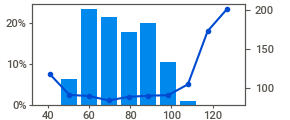
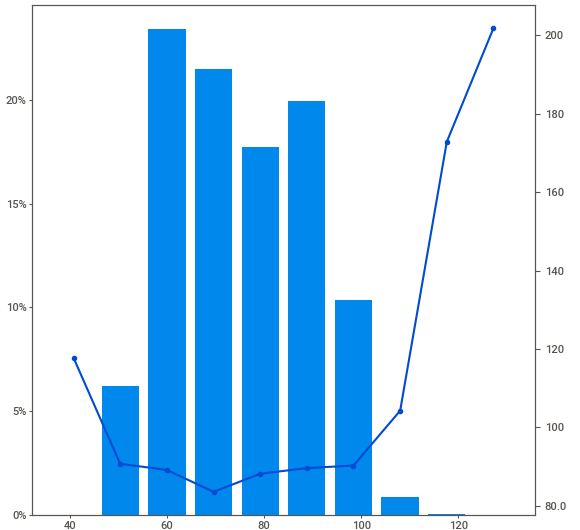
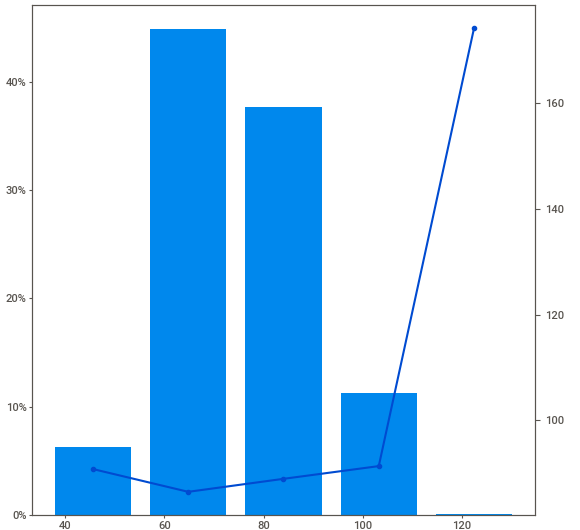
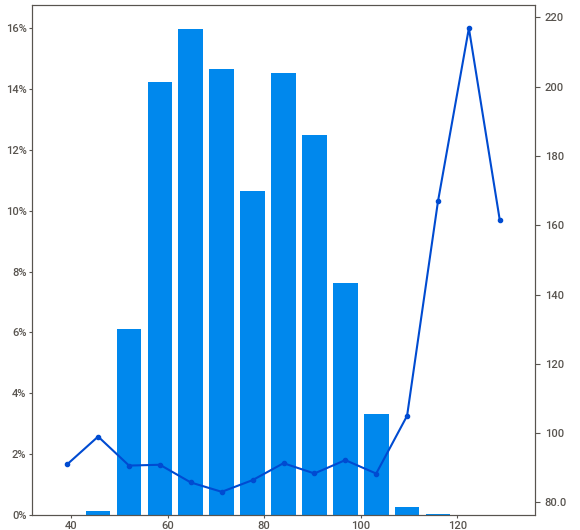
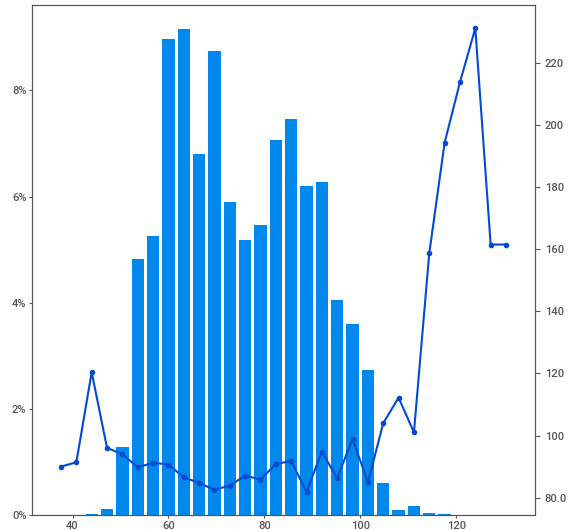
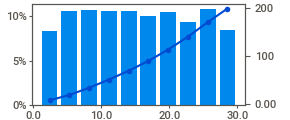
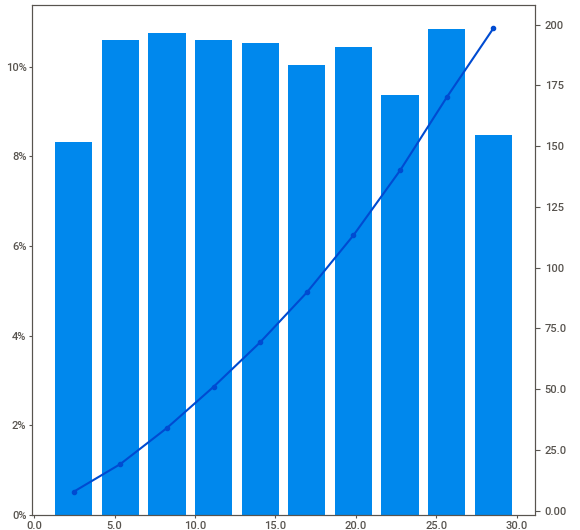
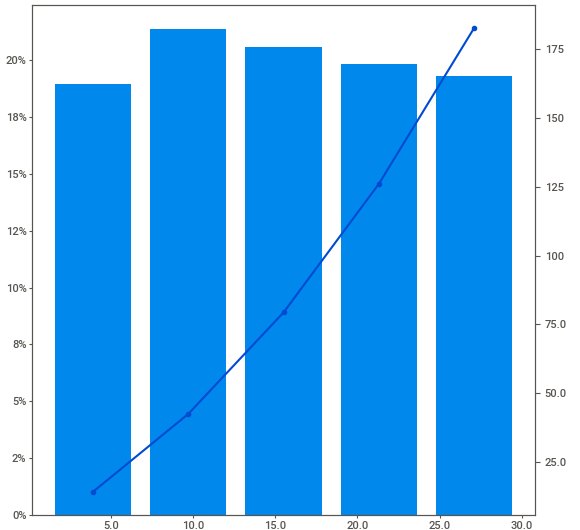
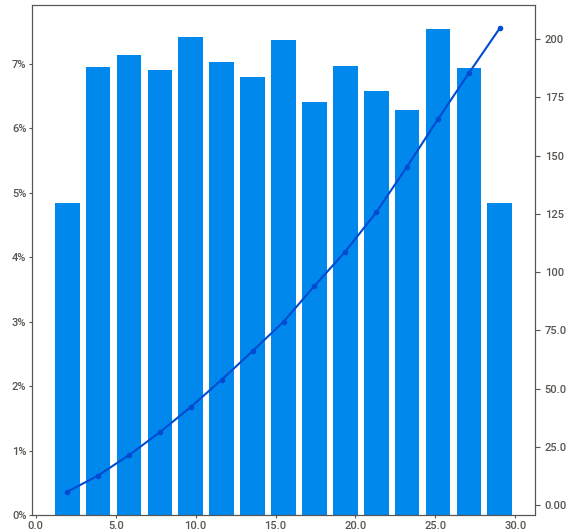
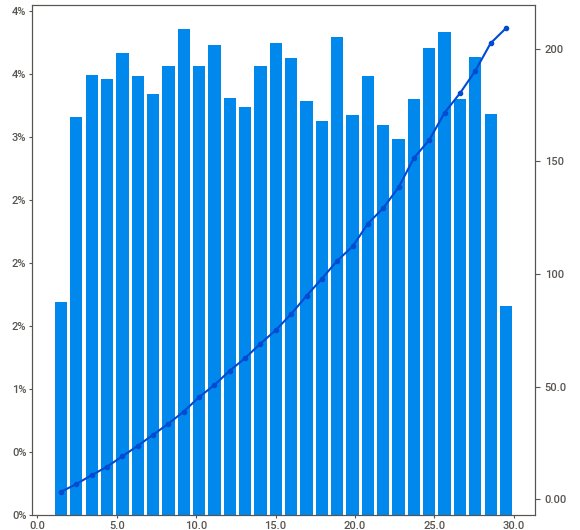
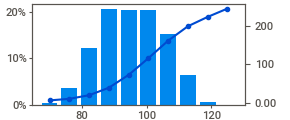
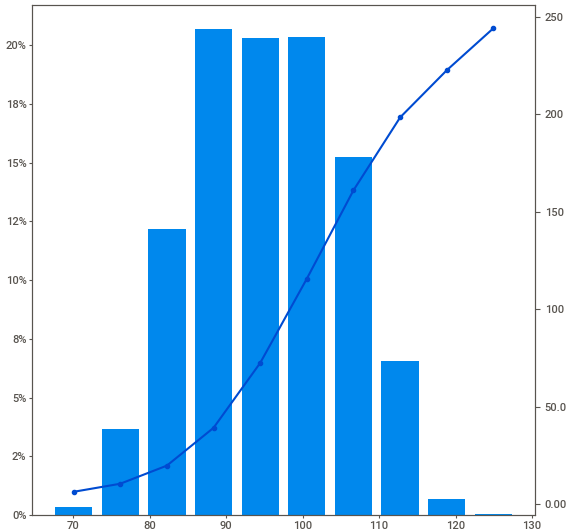
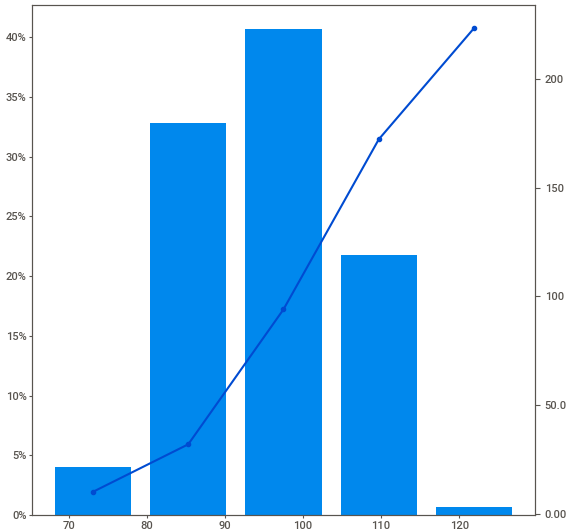
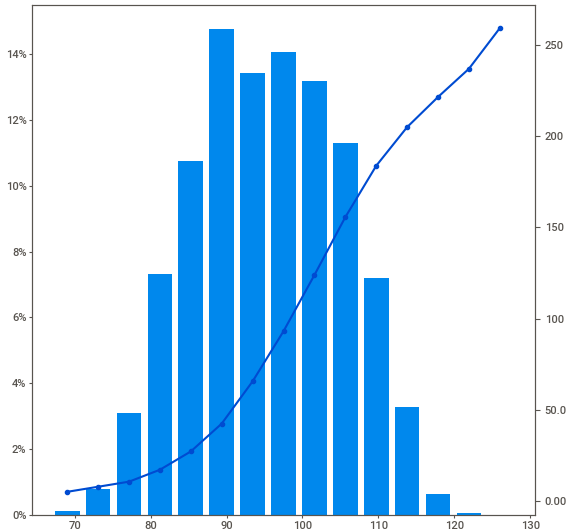
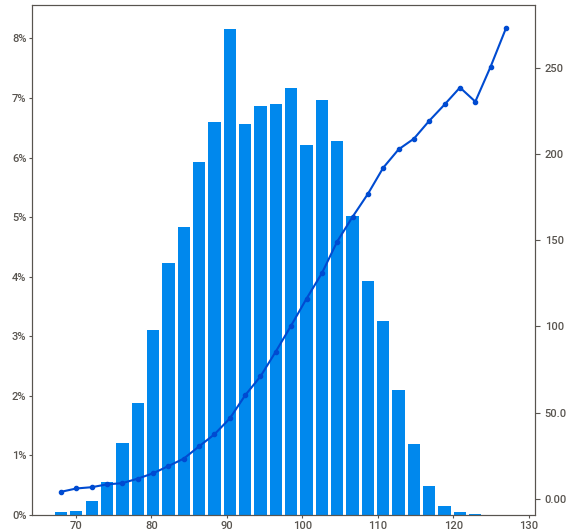
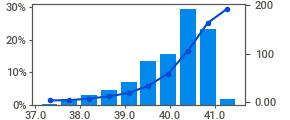
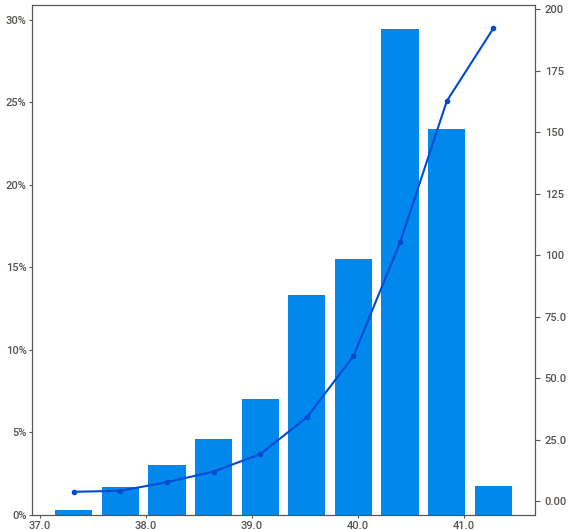
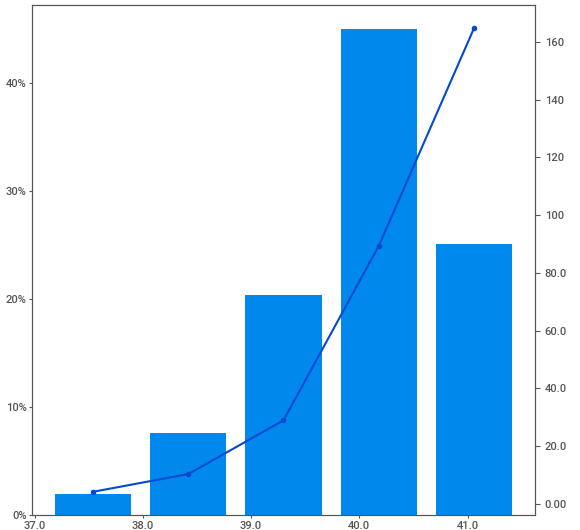
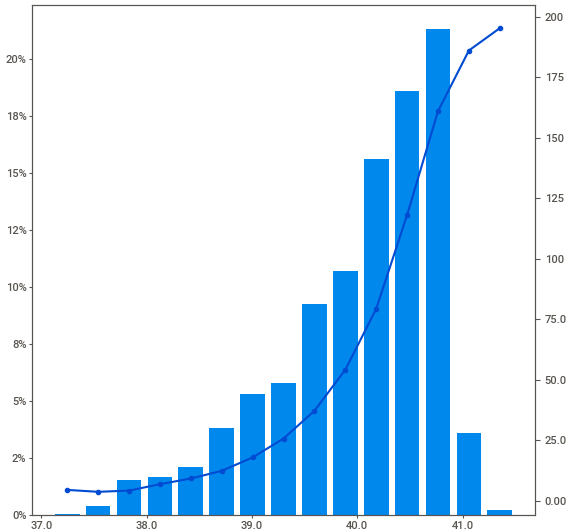
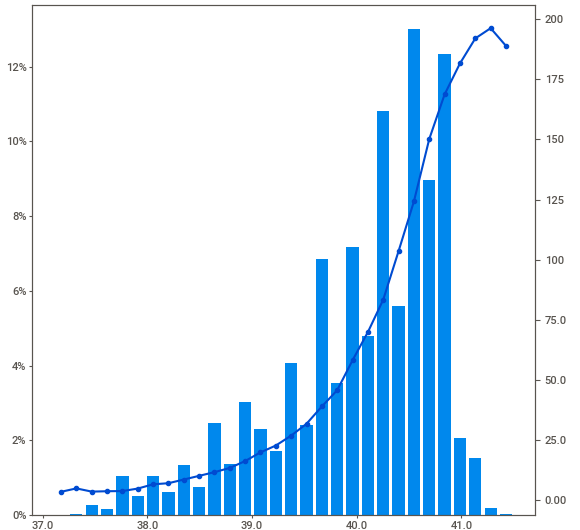
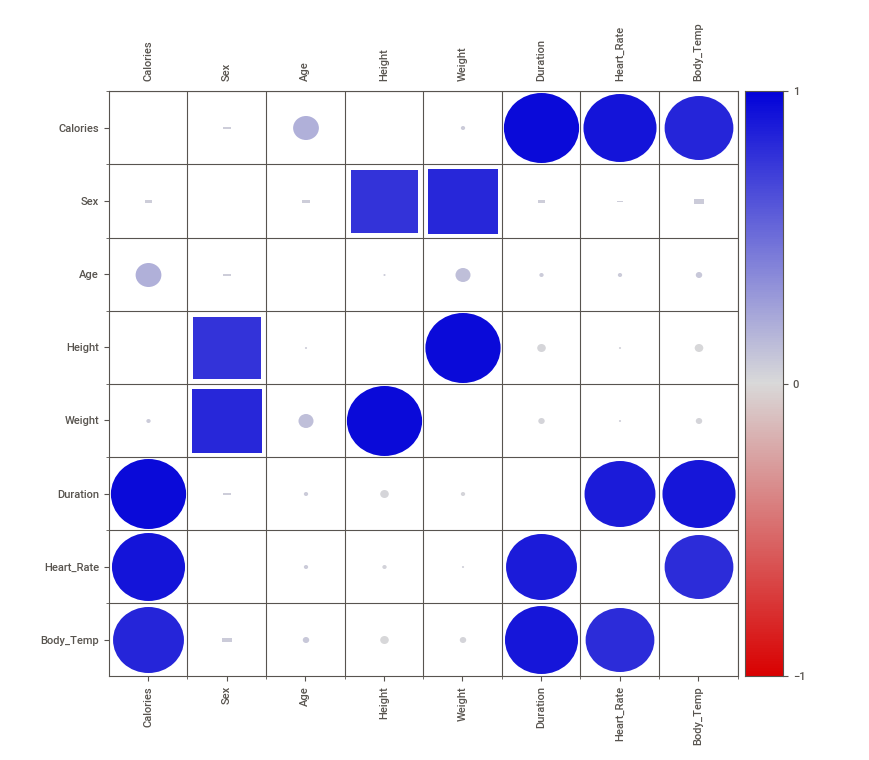
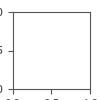

In [10]:
# We pass the data to the profiler

calories_report = sv.analyze([calories_train, "Train"], target_feat="Calories")

# We use the comparison function of the tool

#calories_compare = sv.compare(source=calories_train, compare=calories_test, target_feat="MedHouseVal")

# Get the full profile

calories_report.show_notebook(w="100%", h="full")

### Calories (Target variable)

Our target variable. Highly correlated with body temperature, heart rate, and duration. We found no null or erroneous values, with a positively skewed distribution. The average value is around 88 calories, with a range of values from 1 to 314, with the lowest values having a wider frequency.

### Sex

The only categorical variable we found in the data. We found no erroneous or missing values, and the distribution of values is almost 50/50 for each present value. The variable has a high correlation, as expected, with height and weight.

### Age

We found no null or erroneous values. The age range spans from 20 to 79 years, with a larger presence of lower values, and a skewed distribution to the right. The average age is around 40, and could be replaced by an age range variable.

### Height

No missing or erroneous values were found. The values are represented in centimeters, with an average height of 1.70 meters (the averages, minimums, and maximums by sex and age could be analyzed later). We found some potential outliers when, logically, we approached the minimum and maximum height values. We found a distribution that could be described as symmetrical, with almost the same mean and average values, and similar frequencies on the left and right. The height range is 126 to 222 centimeters, with a high correlation between height and sex.

### Weight

We found something similar with the height variable. There were no null or erroneous values, but we observed some outliers. The distribution is skewed with a small tail to the right. We took the values for this variable in kilograms, with a weight range of 36 to 132 kilos, with an average weight of 75 kg. It could also be separated into weight ranges. We found it logically correlated with sex and height.

### Duration

We will define this variable as the amount of time exercised in minutes. We found no null or erroneous values, and a possible symmetrical distribution, with a mean and average of around 15 minutes. The range of values spans from 1 to 30 minutes. We could separate it into exercise intensity categories (Low, Moderate, Intense). Logically, this is the variable most linearly correlated with calories expended.

### Heart_Rate

We find the variable heart rate, which measures the number of beats per minute. A normal heart rate at rest is between 60 and 100 beats per minute. The average heart rate during exercise depends on the intensity and type of activity. The target heart rate during moderate-intensity exercise is between 50% and 70% of the maximum heart rate, while for vigorous exercise it is 70% to 85%. We found no null or erroneous values, with a possible symmetrical distribution, with the mean and average around 95 beats per minute. The range of values is between 67 and 128 beats per minute. We could relate the variable to duration to expand the features. We found it highly correlated with duration and calories.

### Body_Temp

Average body temperature during intense exercise can temporarily rise to 40°C (104°F). The ideal temperature during exercise and competition is considered to be around 38.5°C. Normal resting body temperature ranges from 36.1°C (97°F) to 37.2°C (99°F). We found no null or erroneous values, and a left-tailed or negatively skewed distribution. The range of values is between 37 and 41 degrees Celsius, with the presence of possible outliers. We could obtain new variables from their relationship with duration, in addition to a possible separation into categories by temperature range. The variable is logically highly correlated with duration.

## Outlier Analysis

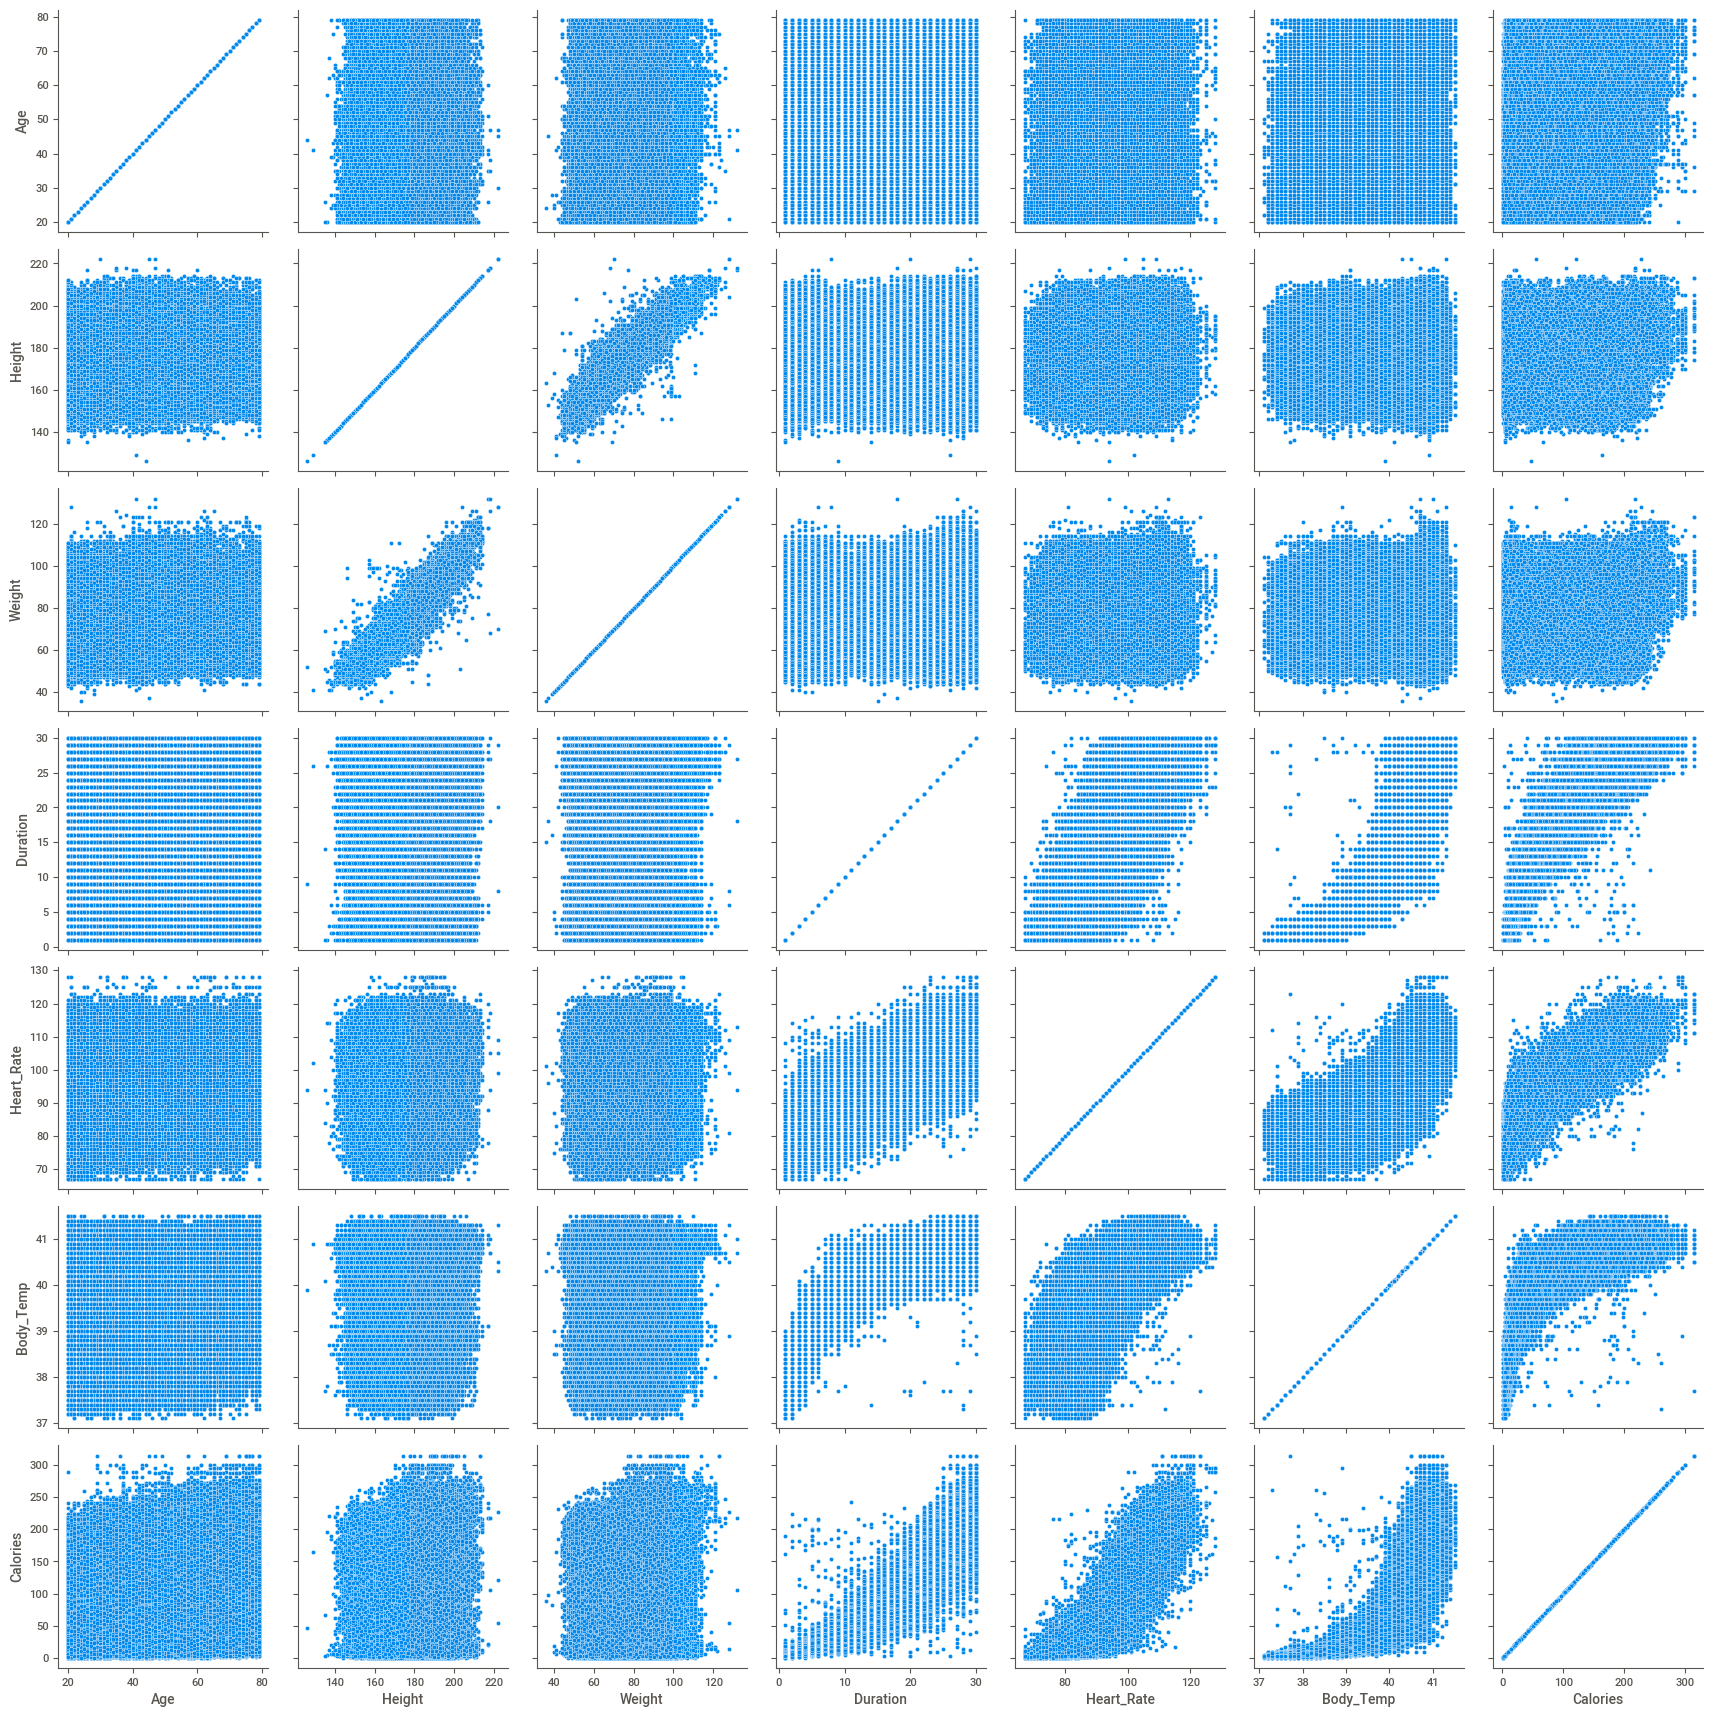

In [11]:
eval_out = sns.PairGrid(calories_train)
eval_out.map(sns.scatterplot)
#eval_out.map_upper(sns.scatterplot)
#eval_out.map_lower(sns.kdeplot)
#eval_out.map_diag(sns.kdeplot, lw=3, legend=False)

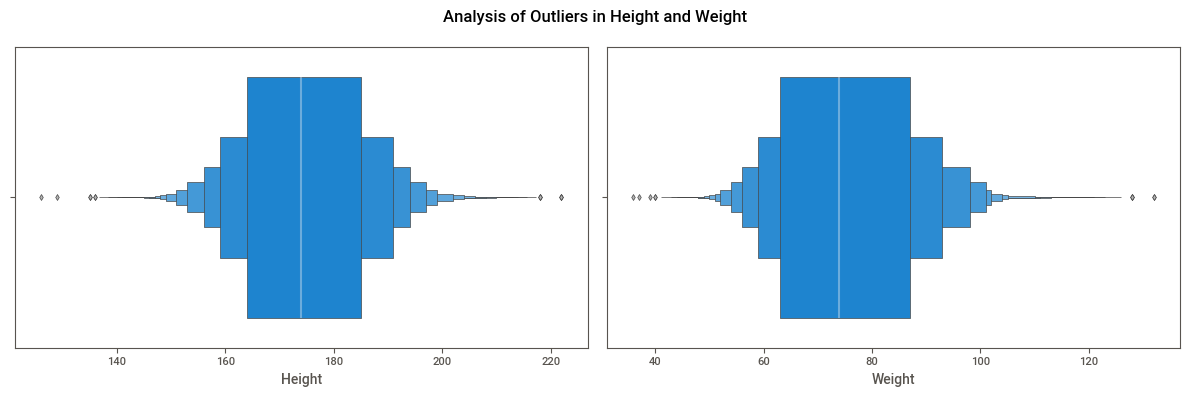

In [12]:
# We analyze the Height & Weight

fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

sns.boxenplot(
    data=calories_train,
    x="Height", 
    linewidth=.5,
    line_kws=dict(linewidth=1.5, color="#cde"),
    flier_kws=dict(facecolor=".7", linewidth=.5),
    ax=axes[0]
)

sns.boxenplot(
    data=calories_train,
    x="Weight",
    linewidth=.5,
    line_kws=dict(linewidth=1.5, color="#cde"),
    flier_kws=dict(facecolor=".7", linewidth=.5),
    ax=axes[1]
)

plt.suptitle(t="Analysis of Outliers in Height and Weight")
plt.tight_layout()
plt.show()

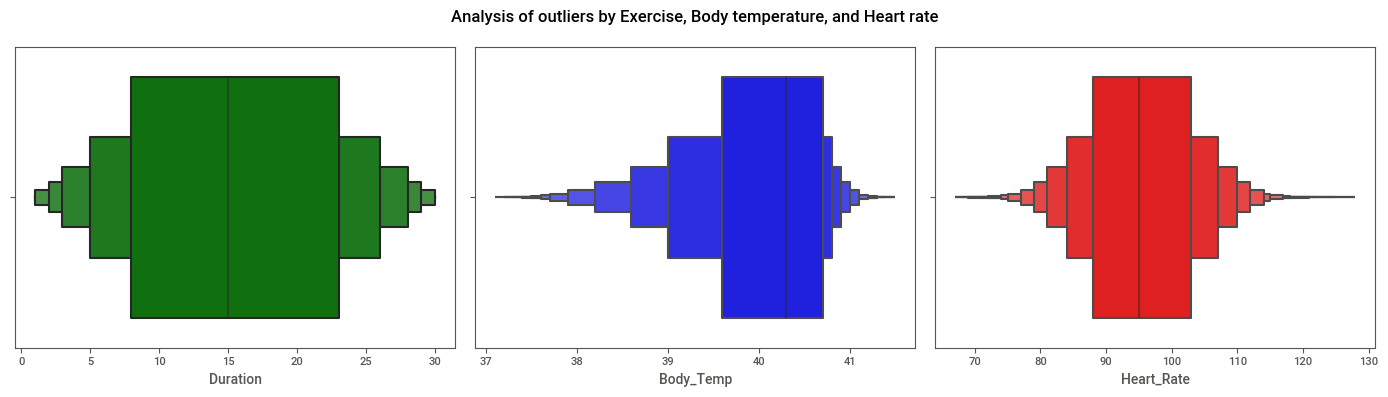

In [13]:
# We analyze the Height & Weight

fig, axes = plt.subplots(ncols=3, figsize=(14, 4))

sns.boxenplot(x=calories_train["Duration"], color="g", ax=axes[0])
sns.boxenplot(x=calories_train["Body_Temp"], color="b",ax=axes[1])
sns.boxenplot(x=calories_train["Heart_Rate"], color="r",ax=axes[2])

plt.suptitle(t="Analysis of outliers by Exercise, Body temperature, and Heart rate")
plt.tight_layout()
plt.show()

We found some outliers that we could handle with an upper threshold and lower threshold value and assign those same values to all data points above or below that threshold accordingly, or convert the features values into bins.

Next, we'll perform data cleaning where necessary, in addition to handling any duplicate values we find (representing 0.3% of the data). Later, as I mentioned previously, we'll likely expand the data analysis for each variable as we progress through our initial approach.

# Data wrangling

After our exploratory data analysis, we found no missing or erroneous data. We did find duplicate data, as well as possible outliers.

In [14]:
# We make a copy of the original dataset

calories_new = calories_train.copy()

In [15]:
# We confirm that there is no null values

null_values = pd.DataFrame(
        {f"Null Data" : calories_new.isnull().sum(), 
         "Percentage" : (calories_new.isnull().sum()) / (len(calories_new)) * (100)})

null_values

,Null Data,Percentage
Sex,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
Duration,0,0.0
Heart_Rate,0,0.0
Body_Temp,0,0.0
Calories,0,0.0


## Outliers

In [16]:
# We replace with an upper threshold(95%) and lower threshold(5%) approximate value

calories_new["Height"] = calories_new["Height"].clip(lower=155.0, upper=200.0).round(decimals=1)
calories_new["Weight"] = calories_new["Weight"].clip(lower=50.0, upper=110.0).round(decimals=1)
calories_new["Heart_Rate"] = calories_new["Heart_Rate"].clip(lower=75.0, upper=115.0).round(decimals=1)
calories_new["Body_Temp"] = calories_new["Body_Temp"].clip(lower=38.00, upper=41.00).round(decimals=1)

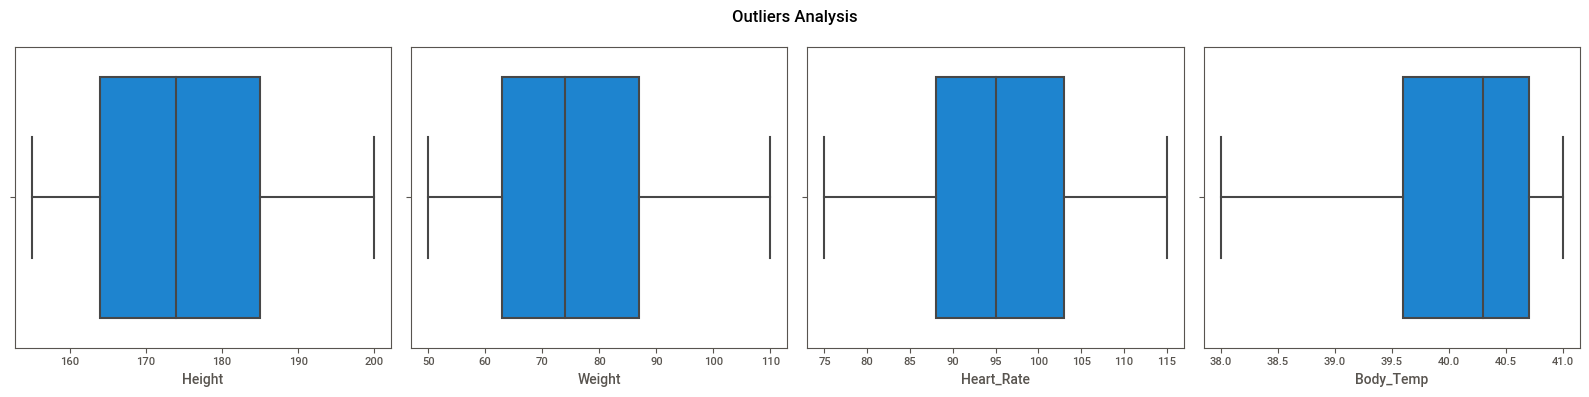

In [17]:
fig, axes = plt.subplots(ncols=4, figsize=(16, 4))

sns.boxplot(x=calories_new["Height"], ax=axes[0])
sns.boxplot(x=calories_new["Weight"], ax=axes[1])
sns.boxplot(x=calories_new["Heart_Rate"], ax=axes[2])
sns.boxplot(x=calories_new["Body_Temp"], ax=axes[3])

plt.suptitle(t="Outliers Analysis")
plt.tight_layout()
plt.show()

## Duplicates

In [18]:
# We check the duplicate data found

print(f"Length: {len(calories_new.duplicated())}")
print(f"Duplicates: {calories_new.duplicated().sum()}")

Length: 750000
Duplicates: 3729


In [19]:
# Removing duplicates and keeping the first occurrence

calories_new.drop_duplicates(inplace=True)

# We check that no duplicate data is found

print(f"Length: {len(calories_new.duplicated())}")
print(f"Duplicates: {calories_new.duplicated().sum()}")

Length: 746271
Duplicates: 0


In [20]:
calories_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 746271 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         746271 non-null  object 
 1   Age         746271 non-null  int64  
 2   Height      746271 non-null  float64
 3   Weight      746271 non-null  float64
 4   Duration    746271 non-null  float64
 5   Heart_Rate  746271 non-null  float64
 6   Body_Temp   746271 non-null  float64
 7   Calories    746271 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 51.2+ MB


We'll keep this initial cleanup simple. After our first run-through, we'll try handling the data differently if necessary. Next we will pose some interesting questions to explore the data in greater depth.

# Hypotheses & Questions of Interest

We'll attempt a more in-depth analysis, not so much trying to understand the variables themselves, but rather the data as a whole, analyzing the information it contains. We'll ask some questions to help us better understand how the data are related and their importance.

In [21]:
# Establishing the seaborn aesthetic

sns.set_style("dark")

- What are the differences in calorie expenditure by sex?
- How much does a person's age influence calorie expenditure?

In [22]:
gender_ce = calories_new.pivot(columns="Sex", values="Calories")

gender_ce.describe().T

,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
female,373807.0,87.648974,57.897258,1.0,37.0,80.0,134.0,300.0
male,372464.0,89.164158,66.542895,1.0,32.0,74.0,138.0,314.0


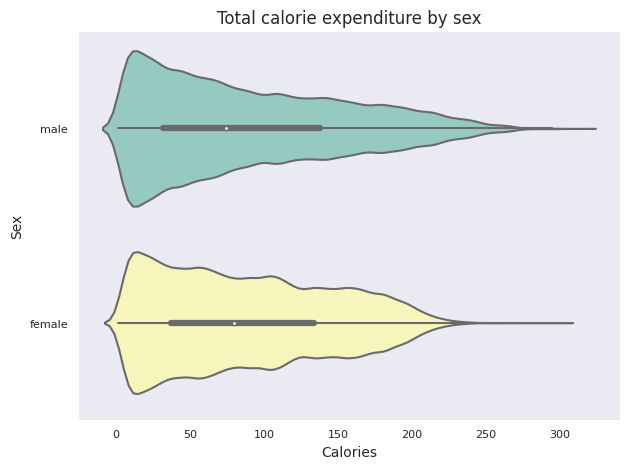

In [23]:
# We analyze the Gender

sns.violinplot(
    data=calories_new, 
    x="Calories",
    y="Sex",
    estimator="sum",
    palette="Set3",
    edgecolor="k"
)

plt.title(label="Total calorie expenditure by sex")
plt.tight_layout()
plt.show()

We didn't find any significant differences in calorie expenditure by gender. One possibility could be the distribution of the dataset values, which were almost identical for each value. We can observe a small, but not significant, difference at the average and maximum values, giving a higher calorie expenditure percentage for men. We'll analyze the amount of exercise time later to examine the gender differences in more depth.

In [24]:
sex_ce = calories_new.pivot(columns="Age", values="Calories")

sex_ce.describe()

Age,20,21,22,23,24,25,26,27,28,29,...,70,71,72,73,74,75,76,77,78,79
count,26085.000000,36064.000000,21187.000000,14605.000000,17747.000000,20482.000000,20672.000000,14437.000000,17989.000000,16735.000000,...,3968.000000,6732.000000,5001.000000,5451.000000,3791.000000,4032.000000,1078.000000,1706.000000,1606.000000,4273.000000
mean,69.612191,80.244205,83.744844,83.478740,72.889446,79.690313,80.763690,79.281222,79.030241,79.163490,...,97.002268,92.723708,101.438712,109.352229,104.137431,131.508929,169.916512,156.632474,141.610834,118.536859
std,51.299073,55.210056,57.191283,54.422248,56.084098,58.436709,56.373637,54.197232,57.973901,55.168145,...,79.334599,63.690435,76.921806,78.400596,71.211175,72.751593,80.708909,81.320454,85.887073,72.786034
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2.000000,3.000000,2.000000,1.000000,3.000000,2.000000,5.000000,3.000000,2.000000,4.000000
25%,24.000000,30.000000,32.000000,35.000000,24.000000,24.000000,31.000000,33.000000,26.000000,32.000000,...,28.750000,44.000000,39.000000,43.000000,46.000000,66.000000,106.250000,76.000000,55.000000,53.000000
50%,60.000000,75.000000,76.000000,78.000000,60.000000,71.000000,74.000000,72.000000,67.000000,70.000000,...,65.000000,79.000000,79.000000,87.000000,77.000000,144.000000,185.000000,182.000000,165.000000,105.000000
75%,108.000000,124.000000,129.000000,128.000000,114.000000,129.000000,125.000000,119.000000,125.000000,118.000000,...,171.250000,126.000000,171.000000,182.000000,166.000000,179.000000,242.000000,222.000000,216.000000,181.000000
max,289.000000,230.000000,240.000000,240.000000,230.000000,259.000000,243.000000,250.000000,251.000000,314.000000,...,300.000000,300.000000,300.000000,314.000000,300.000000,314.000000,314.000000,314.000000,295.000000,314.000000


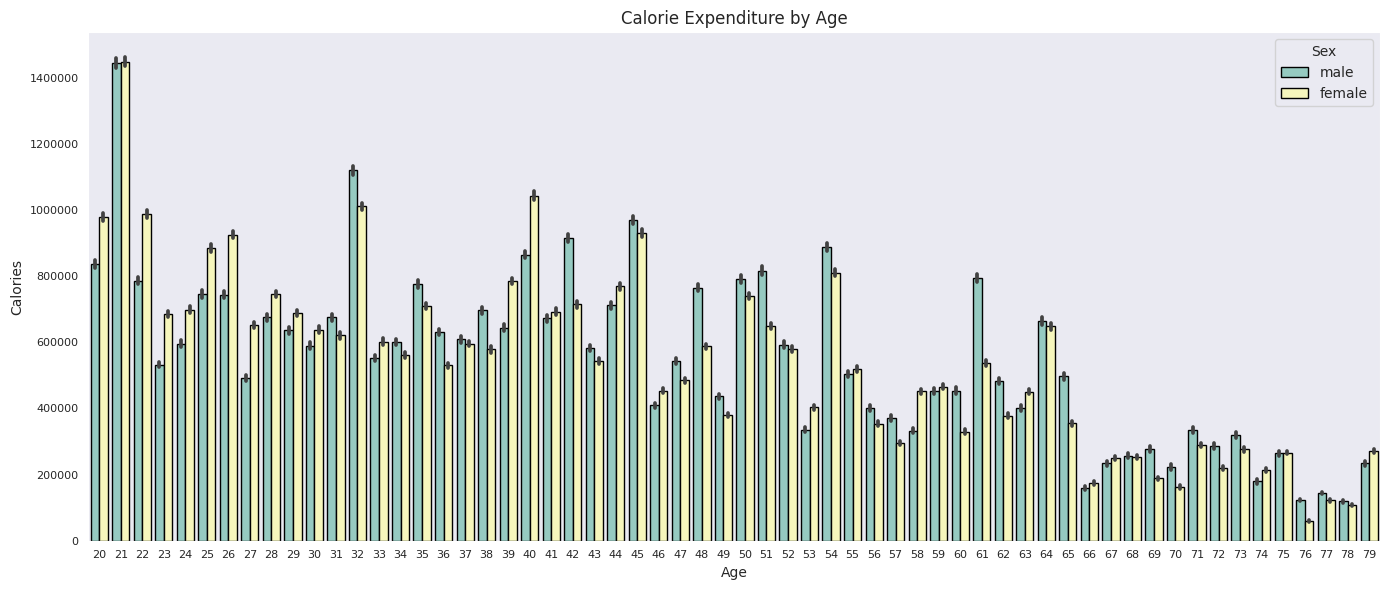

In [25]:
# We analyze the Age

fig, axes = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=calories_new, 
    x="Age",
    y="Calories",
    estimator="sum",
    hue="Sex",
    palette="Set3",
    edgecolor="k"
)

plt.title(label="Calorie Expenditure by Age")
plt.tight_layout()
plt.show()

As might be expected, we found higher calorie expenditure in young people. However, we didn't find significant differences in the overall age average. Separating these into age groups could be a good option.

- Is height or weight an important factor in calorie expenditure?
- How much does height and weight influence calorie expenditure by gender?

In [26]:
height_ce = calories_new.pivot(columns="Height", values="Calories")

height_ce.describe()

Height,155.0,156.0,157.0,158.0,159.0,160.0,161.0,162.0,163.0,164.0,...,191.0,192.0,193.0,194.0,195.0,196.0,197.0,198.0,199.0,200.0
count,44190.000000,11670.000000,11611.000000,18154.000000,14136.000000,13149.000000,26048.000000,16314.000000,18057.000000,20085.000000,...,17563.000000,13572.000000,13181.000000,11795.000000,7180.000000,8267.000000,5910.000000,3920.000000,4837.000000,11305.000000
mean,91.547703,94.607969,89.988201,96.695384,91.358093,84.582706,90.596092,88.752237,85.909010,86.639183,...,86.818368,80.617963,80.406494,79.655871,93.790390,101.924640,81.689509,98.653316,83.184205,103.239275
std,59.719316,59.113756,59.904210,57.453256,57.635956,56.700566,55.319483,58.435889,57.487904,57.481231,...,66.051839,68.691284,64.357394,62.023190,66.683694,72.741206,64.503773,69.517122,67.454382,73.819940
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,38.000000,42.000000,34.000000,49.000000,41.000000,33.000000,50.000000,38.000000,34.000000,36.000000,...,32.000000,17.000000,25.000000,28.000000,37.000000,38.000000,23.000000,35.000000,24.000000,31.000000
50%,86.000000,89.500000,84.000000,95.000000,85.000000,80.000000,76.000000,79.000000,79.000000,79.000000,...,72.000000,61.000000,63.000000,65.000000,82.000000,86.000000,67.000000,90.000000,68.000000,99.000000
75%,142.000000,143.000000,141.000000,141.000000,137.000000,127.000000,134.000000,137.000000,128.000000,130.000000,...,131.000000,132.000000,126.000000,121.000000,142.250000,165.000000,123.000000,152.000000,129.000000,154.000000
max,261.000000,241.000000,261.000000,264.000000,259.000000,238.000000,243.000000,264.000000,272.000000,256.000000,...,314.000000,300.000000,300.000000,314.000000,314.000000,314.000000,300.000000,314.000000,314.000000,314.000000


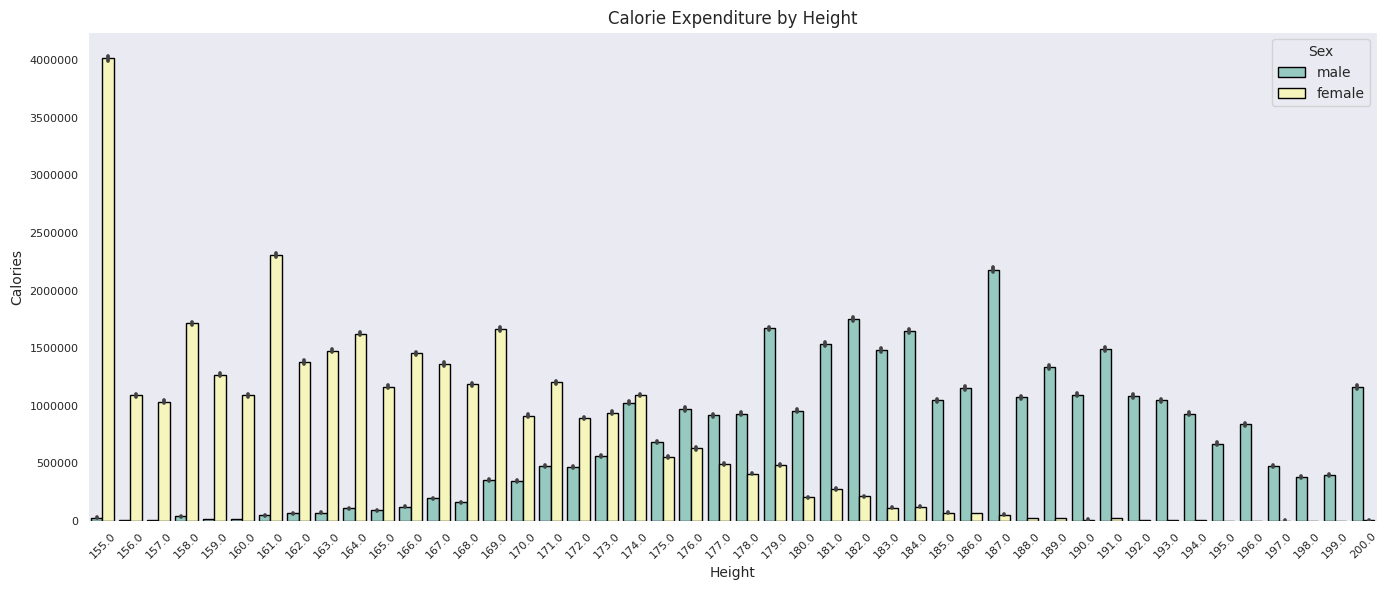

In [27]:
# We analyze the Age

fig, axes = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=calories_new, 
    x="Height",
    y="Calories",
    estimator="sum",
    hue="Sex",
    palette="Set3",
    edgecolor="k"
).tick_params(axis='x', labelrotation=45)

plt.title(label="Calorie Expenditure by Height")
plt.tight_layout()
plt.show()

We found that, on average, calorie expenditure by height falls within the same range; it's at the highest values where we begin to observe an increase. Analyzing the graph, we can see, as expected, that the values for men have a negative skewness, with a tail to the left, and a positive skewness for women. In the center of the graph, where we can see the average height values, calorie expenditure is similar for both.

In [28]:
weight_ce = calories_new.pivot(columns="Weight", values="Calories")

weight_ce.describe()

Weight,50.0,51.0,52.0,53.0,54.0,55.0,56.0,57.0,58.0,59.0,...,101.0,102.0,103.0,104.0,105.0,106.0,107.0,108.0,109.0,110.0
count,4438.000000,5989.000000,6630.000000,5220.000000,13233.000000,10799.000000,12640.000000,12054.000000,14699.000000,18638.000000,...,6151.000000,7956.000000,3379.000000,3491.000000,532.000000,433.000000,293.000000,221.000000,192.000000,1654.000000
mean,98.324020,92.042244,98.552640,88.990805,82.050782,94.953144,95.085443,94.772524,85.077828,87.007619,...,78.168590,83.909879,97.035513,93.627614,143.308271,140.071594,122.744027,97.393665,112.927083,118.603990
std,63.522269,62.791520,57.972805,57.936552,54.550629,59.340573,60.142713,60.968261,57.472962,60.795976,...,62.516191,66.165566,64.736309,67.925870,83.995398,88.381365,89.198213,92.532322,90.027598,90.026082
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,2.000000,1.000000,2.000000,2.000000,1.000000,3.000000,2.000000,1.000000
25%,35.000000,34.000000,44.000000,36.750000,35.000000,42.000000,39.000000,40.000000,33.000000,31.000000,...,23.000000,21.000000,42.000000,29.000000,63.750000,43.000000,18.000000,14.000000,19.750000,19.000000
50%,101.000000,85.000000,100.000000,84.000000,74.000000,92.000000,94.000000,90.000000,78.000000,78.000000,...,64.000000,70.000000,89.000000,83.000000,162.000000,164.000000,137.000000,30.000000,98.000000,129.000000
75%,156.000000,150.000000,146.000000,139.000000,118.000000,145.000000,147.000000,147.000000,129.000000,138.000000,...,112.000000,135.000000,143.000000,144.000000,218.250000,220.000000,213.000000,202.000000,193.000000,207.000000
max,242.000000,252.000000,242.000000,249.000000,240.000000,256.000000,247.000000,261.000000,256.000000,264.000000,...,300.000000,314.000000,314.000000,295.000000,314.000000,276.000000,314.000000,268.000000,266.000000,314.000000


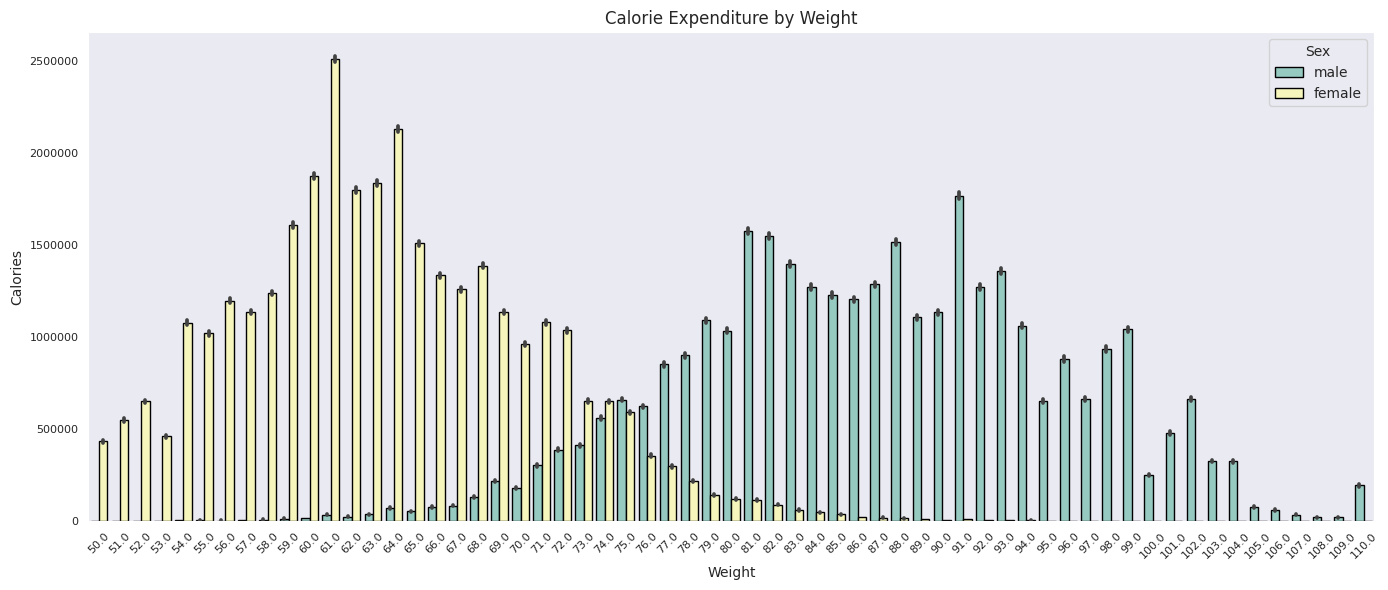

In [29]:
# We analyze the Age

fig, axes = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=calories_new, 
    x="Weight",
    y="Calories",
    estimator="sum",
    hue="Sex",
    palette="Set3",
    edgecolor="k"
).tick_params(axis='x', labelrotation=45)

plt.title(label="Calorie Expenditure by Weight")
plt.tight_layout()
plt.show()

Unlike height, we find different averages across the board, with the person's calorie expenditure being higher as the weight increases. Regarding the maximum and minimum values, we see a similar difference as with height, but less pronounced. Looking at the graph, we can observe the same logic as with height: a negative skewness for men, a positive skewness for women, and the same values when analyzing the average weight for both.

- What is the average calorie expenditure for the duration of exercise?
- What differences do we find in exercise duration by age and sex?

In [30]:
duration_ce = calories_new.pivot(columns="Duration", values="Calories")

duration_ce.describe()

Duration,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0
count,12163.000000,23364.000000,25979.000000,25792.000000,27296.000000,26028.000000,24977.000000,26680.000000,28693.000000,26597.000000,...,26007.000000,23152.000000,22307.000000,24708.000000,27676.000000,28683.000000,24684.000000,27134.000000,23758.000000,12431.000000
mean,3.365206,6.840353,10.757843,14.510623,19.147055,23.766213,28.694159,33.602211,38.991670,45.404256,...,122.389818,129.294186,138.501322,151.531771,159.562365,171.606945,180.259277,190.179996,202.387028,209.081409
std,2.683731,3.117390,3.300240,4.115830,5.034964,5.721345,5.995570,6.967874,7.726277,8.560296,...,17.022566,17.726710,18.641744,21.545446,22.489273,23.639101,25.484403,25.147583,26.776140,26.729417
min,1.000000,1.000000,2.000000,1.000000,3.000000,3.000000,6.000000,4.000000,7.000000,5.000000,...,15.000000,42.000000,10.000000,10.000000,15.000000,3.000000,18.000000,10.000000,13.000000,41.000000
25%,3.000000,6.000000,9.000000,12.000000,17.000000,21.000000,25.000000,29.000000,34.000000,41.000000,...,112.000000,118.000000,127.000000,137.000000,145.000000,156.000000,163.000000,173.000000,185.000000,192.000000
50%,3.000000,7.000000,11.000000,15.000000,19.000000,24.000000,29.000000,34.000000,40.000000,46.000000,...,121.000000,129.000000,138.000000,149.000000,157.000000,168.000000,178.000000,187.000000,200.000000,207.000000
75%,4.000000,8.000000,12.000000,17.000000,22.000000,27.000000,32.000000,38.000000,44.000000,51.000000,...,132.000000,140.000000,149.000000,164.000000,172.000000,184.000000,194.000000,203.000000,217.000000,225.000000
max,189.000000,223.000000,207.000000,215.000000,200.000000,215.000000,178.000000,184.000000,198.000000,195.000000,...,221.000000,235.000000,241.000000,264.000000,295.000000,314.000000,314.000000,314.000000,314.000000,314.000000


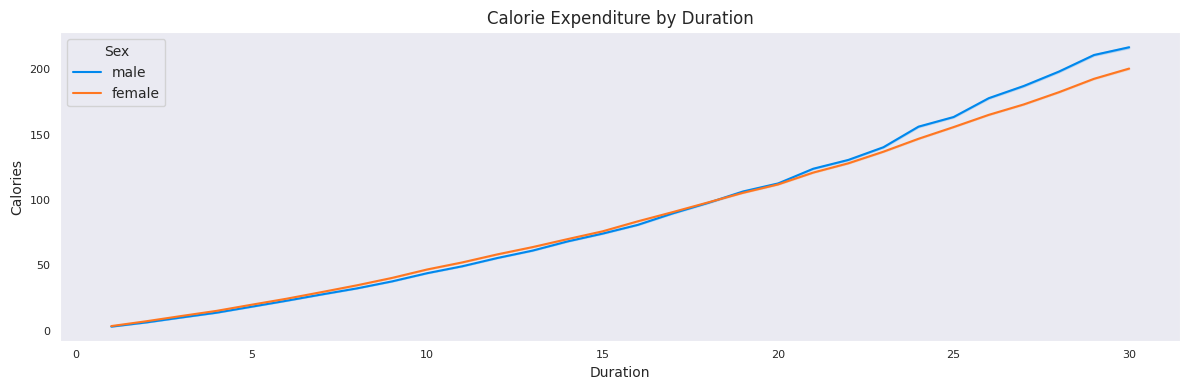

In [31]:
# We analyze the duration & calorie expenditure

fig, axes = plt.subplots(figsize=(12, 4))

sns.lineplot(
    data=calories_new, 
    x="Duration",
    y="Calories",
    hue="Sex"
)

plt.title(label="Calorie Expenditure by Duration")
plt.tight_layout()
plt.show()

Logically, the relationship between these variables is linear: the more exercise, the greater the calorie expenditure, although other factors, such as weight or height, should be influential in identifying possible discrepancies.

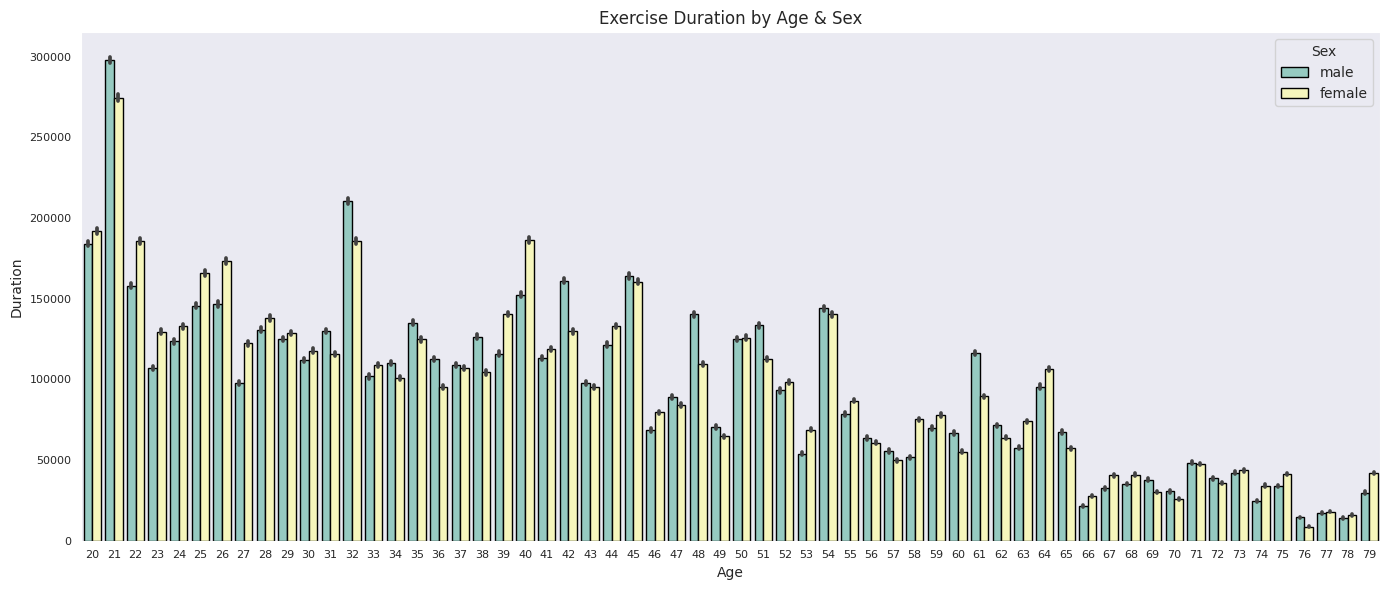

In [32]:
# We analyze the Age

fig, axes = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=calories_new, 
    x="Age",
    y="Duration",
    estimator="sum",
    hue="Sex",
    palette="Set3",
    edgecolor="k"
)

plt.title(label="Exercise Duration by Age & Sex")
plt.tight_layout()
plt.show()

We didn't observe significant differences between genders; we found that both men and women maintained a similar average duration of exercise. What we did see was that age was an important factor in determining the duration of exercise. Younger people tended to do longer workouts.

- How does exercise impact heart rate and body temperature, is gender a factor?
- What are the average temperatures and heart rate for each duration?

In [33]:
duration_hr = calories_new.pivot(columns="Heart_Rate", values="Duration")

duration_hr.describe()

Heart_Rate,75.0,76.0,77.0,78.0,79.0,80.0,81.0,82.0,83.0,84.0,...,106.0,107.0,108.0,109.0,110.0,111.0,112.0,113.0,114.0,115.0
count,6673.000000,4005.000000,4946.000000,5662.000000,8351.000000,8901.000000,14034.000000,15852.000000,15672.000000,16825.00000,...,17864.000000,19744.000000,16885.000000,12551.000000,12914.000000,11461.000000,8793.000000,6916.000000,5473.000000,8673.000000
mean,3.055297,3.220724,3.497978,3.885906,4.028500,4.640827,4.554510,5.305198,5.565722,5.74627,...,24.642017,25.175294,25.876281,25.739463,26.743689,26.729430,27.192540,27.158473,27.406724,27.701603
std,2.056698,2.108264,2.356433,2.510050,2.493182,2.859731,2.781488,2.995291,3.186764,3.29216,...,3.547060,3.145015,3.042681,3.090611,2.670785,2.668247,2.422808,2.487287,2.101962,2.075038
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,2.000000,3.000000,1.000000,2.000000,2.000000,4.000000,4.000000,3.000000,2.000000,4.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.00000,...,23.000000,23.000000,24.000000,24.000000,25.000000,25.000000,26.000000,26.000000,26.000000,27.000000
50%,2.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.00000,...,25.000000,26.000000,26.000000,26.000000,27.000000,27.000000,28.000000,28.000000,28.000000,28.000000
75%,4.000000,4.000000,4.750000,5.000000,5.000000,6.000000,6.000000,7.000000,7.000000,8.00000,...,27.000000,28.000000,28.000000,28.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
max,26.000000,28.000000,25.000000,25.000000,25.000000,29.000000,26.000000,30.000000,26.000000,25.00000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000


In [34]:
duration_bt = calories_new.pivot(columns="Body_Temp", values="Duration")

duration_bt.describe()

Body_Temp,38.0,38.1,38.2,38.3,38.4,38.5,38.6,38.7,38.8,38.9,...,40.1,40.2,40.3,40.4,40.5,40.6,40.7,40.8,40.9,41.0
count,18137.000000,3964.000000,4508.000000,5889.000000,4143.000000,5682.000000,9125.000000,9249.000000,10095.000000,9982.000000,...,35841.000000,32051.000000,48794.000000,41877.000000,49435.000000,47945.000000,66847.000000,52548.000000,39782.000000,28405.000000
mean,1.396482,2.028254,2.110692,2.302598,2.615255,2.851461,3.068822,3.496270,3.739574,4.088559,...,14.003571,15.312596,16.533037,18.511880,19.980419,22.204046,23.831601,25.319993,26.142678,27.259321
std,0.755216,0.413876,0.434216,0.609978,0.666273,0.776870,0.680954,0.882238,0.882785,0.933288,...,2.596763,2.881059,3.121861,3.655212,3.722532,3.744880,3.352005,3.134127,2.919541,2.350815
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.000000,5.000000,4.000000,5.000000,7.000000,6.000000,7.000000,6.000000,7.000000,7.000000
25%,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,4.000000,...,12.000000,13.000000,14.000000,16.000000,17.000000,20.000000,21.000000,23.000000,25.000000,26.000000
50%,1.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,...,14.000000,15.000000,16.000000,18.000000,20.000000,22.000000,24.000000,26.000000,27.000000,28.000000
75%,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,...,16.000000,17.000000,18.000000,21.000000,22.000000,25.000000,26.000000,28.000000,28.000000,29.000000
max,29.000000,6.000000,6.000000,27.000000,6.000000,30.000000,9.000000,29.000000,28.000000,30.000000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000


In [35]:
# Set the style to "darkgrid"

sns.set_style("darkgrid")

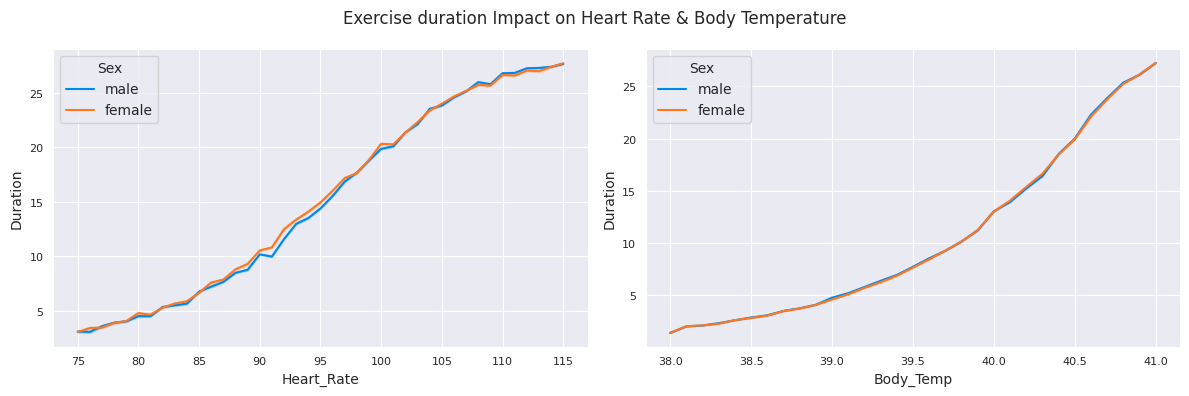

In [36]:
# We plot the duration by Heart Rate & Body Temp

fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

sns.lineplot(
    data=calories_new, 
    x="Heart_Rate",
    y="Duration",
    hue="Sex",
    ax=axes[0]
)

sns.lineplot(
    data=calories_new, 
    x="Body_Temp",
    y="Duration",
    hue="Sex",
    ax=axes[1]
)

plt.suptitle(t="Exercise duration Impact on Heart Rate & Body Temperature")
plt.tight_layout()
plt.show()

As expected, we find, just like calorie expenditure per duration, a linear relationship between the variables. Both heart rate and body temperature increase with increasing exercise duration, in addition to there being no differences regarding gender.

In [37]:
duration_hr_bt = calories_new[["Heart_Rate", "Body_Temp"]].set_index(calories_new["Duration"])

duration_hr_bt.describe()

,Heart_Rate,Body_Temp
count,746271.000000,746271.000000
mean,95.500278,40.041293
std,9.372154,0.758306
min,75.000000,38.000000
25%,88.000000,39.600000
50%,95.000000,40.300000
75%,103.000000,40.700000
max,115.000000,41.000000


Analyzing the data, we found that the average heart rate is 95.5 beats per minute, just within the normal upper limit of 60 to 100. As for average body temperature, we found 40°C, which is above the ideal temperature for exercise and a more appropriate temperature for intense exercise.

- How does heart rate behave when calorie expenditure is taken into account?
- What is the relationship between body temperature and calorie expenditure?

In [38]:
calories_hr = calories_new.pivot(columns="Heart_Rate", values="Calories")

calories_hr.describe()

Heart_Rate,75.0,76.0,77.0,78.0,79.0,80.0,81.0,82.0,83.0,84.0,...,106.0,107.0,108.0,109.0,110.0,111.0,112.0,113.0,114.0,115.0
count,6673.000000,4005.000000,4946.000000,5662.000000,8351.000000,8901.000000,14034.000000,15852.000000,15672.000000,16825.000000,...,17864.000000,19744.000000,16885.000000,12551.000000,12914.000000,11461.000000,8793.000000,6916.000000,5473.000000,8673.000000
mean,7.728308,8.667166,9.748484,11.150830,12.367501,15.147961,14.907225,18.670767,19.692828,21.103477,...,160.298253,166.438462,176.330649,177.425225,191.686000,192.322834,203.499488,201.359167,207.248493,218.531765
std,6.373333,7.209567,7.647427,8.447048,8.449917,10.420713,10.221397,11.767292,11.936277,12.859959,...,28.865989,26.559944,28.406124,28.766968,28.119654,25.398447,30.339852,25.883039,23.300941,27.869162
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,21.000000,16.000000,25.000000,13.000000,31.000000,19.000000,22.000000,40.000000,65.000000,17.000000
25%,3.000000,3.000000,5.000000,6.000000,7.000000,8.000000,8.000000,11.000000,11.000000,11.000000,...,144.000000,150.000000,159.000000,160.000000,176.000000,179.000000,183.000000,187.000000,194.000000,203.000000
50%,6.000000,8.000000,8.000000,10.000000,10.000000,13.000000,12.000000,17.000000,19.000000,20.000000,...,160.000000,166.000000,176.000000,178.000000,190.000000,193.000000,200.000000,199.000000,204.000000,215.000000
75%,10.000000,11.000000,12.000000,14.000000,16.000000,19.000000,20.000000,24.000000,26.000000,28.000000,...,179.000000,182.000000,193.000000,192.000000,209.000000,206.000000,223.000000,217.000000,222.000000,234.000000
max,89.000000,215.000000,90.000000,215.000000,125.000000,183.000000,175.000000,223.000000,185.000000,125.000000,...,269.000000,265.000000,300.000000,300.000000,289.000000,314.000000,289.000000,300.000000,314.000000,314.000000


In [39]:
calories_bt = calories_new.pivot(columns="Body_Temp", values="Calories")

calories_bt.describe()

Body_Temp,38.0,38.1,38.2,38.3,38.4,38.5,38.6,38.7,38.8,38.9,...,40.1,40.2,40.3,40.4,40.5,40.6,40.7,40.8,40.9,41.0
count,18137.000000,3964.000000,4508.000000,5889.000000,4143.000000,5682.000000,9125.000000,9249.000000,10095.000000,9982.000000,...,35841.000000,32051.000000,48794.000000,41877.000000,49435.000000,47945.000000,66847.000000,52548.000000,39782.000000,28405.000000
mean,4.681149,6.636478,7.145519,8.211751,9.348298,10.206089,10.722301,12.765921,13.495493,15.229213,...,69.973940,78.339709,86.844756,103.644196,115.008516,133.860465,150.230242,165.156181,173.357046,186.416969
std,5.328796,2.438296,2.391026,5.043677,5.593212,5.270598,4.906472,5.428764,5.632701,6.736347,...,19.962417,23.422673,26.019942,32.206025,34.871830,37.851797,36.275858,37.461478,36.674746,35.086173
min,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,...,10.000000,5.000000,11.000000,9.000000,20.000000,10.000000,18.000000,10.000000,24.000000,20.000000
25%,3.000000,5.000000,6.000000,7.000000,7.000000,8.000000,8.000000,10.000000,11.000000,12.000000,...,57.000000,62.000000,69.000000,81.000000,91.000000,107.000000,123.000000,139.000000,148.000000,164.000000
50%,4.000000,7.000000,7.000000,8.000000,9.000000,10.000000,10.000000,12.000000,13.000000,15.000000,...,67.000000,75.000000,83.000000,100.000000,109.000000,130.000000,148.000000,165.000000,174.000000,185.000000
75%,6.000000,8.000000,8.000000,9.000000,11.000000,12.000000,13.000000,15.000000,16.000000,18.000000,...,81.000000,91.000000,101.000000,121.000000,135.000000,158.000000,174.000000,190.000000,198.000000,210.000000
max,314.000000,47.000000,24.000000,261.000000,214.000000,256.000000,207.000000,186.000000,189.000000,295.000000,...,208.000000,240.000000,266.000000,295.000000,314.000000,295.000000,314.000000,314.000000,314.000000,314.000000


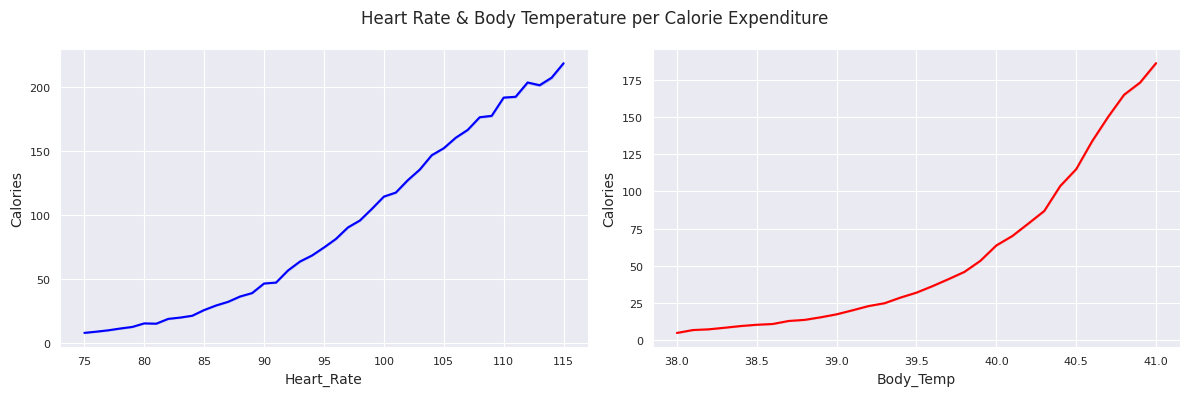

In [40]:
# We plot the calories by Heart Rate & Body Temp

fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

sns.lineplot(
    data=calories_new, 
    x="Heart_Rate",
    y="Calories",
    color="b",
    ax=axes[0]
)

sns.lineplot(
    data=calories_new, 
    x="Body_Temp",
    y="Calories",
    color="r",
    ax=axes[1]
)

plt.suptitle(t="Heart Rate & Body Temperature per Calorie Expenditure")
plt.tight_layout()
plt.show()

As expected, the relationship between both variables and calorie expenditure is very linear. We found the same impact and relationship as with duration, as can be seen from the graphs of both analyses. We did not find it necessary to statistically analyze the overall averages of the two variables with calorie expenditure. Next, we will preprocess the data and begin model selection.

Note: We could extend this analysis by asking a larger number of interesting questions, such as the relationship between a person's weight and heart rate, taking into account that the greater the weight, the greater the effort on the heart. Would it be logical to find a linear relationship? Or how body temperature varies by gender, or the different analyses we could perform taking into account a person's age and the differences between heart rate and body temperature.

# Data Preprocessing

Next we will proceed to perform some feature engineering, encoding the data where necessary, in addition to scaling the values.

In [41]:
calories_end = calories_new.copy()

In [42]:
calories_end.info()

<class 'pandas.core.frame.DataFrame'>
Index: 746271 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         746271 non-null  object 
 1   Age         746271 non-null  int64  
 2   Height      746271 non-null  float64
 3   Weight      746271 non-null  float64
 4   Duration    746271 non-null  float64
 5   Heart_Rate  746271 non-null  float64
 6   Body_Temp   746271 non-null  float64
 7   Calories    746271 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 51.2+ MB


## Feature Engineering

There are several approaches we could take, but we'll keep it simple initially and then expand the number of features. For now, we'll focus solely on age and duration, binning the columns and setting the corresponding labels. I'll leave it to you to explore other ideas with this data.

Note: This step is more interesting to perform in the data management section, so then we could ask some relevant questions and conduct an in-depth analysis of the created features, while maintaining certain order in the notebook.

In [43]:
# We separate the Age variable into bins

bins_age = [0, 40, 60, 80]

# Specify bin labels

labels_age = ["Young", "MiddleAge", "Old"]

# We created the new feature

calories_end["Age_Bins"] = pd.cut(calories_end["Age"], bins_age, labels=labels_age)

In [44]:
# We separate the Duration variable into bins

bins_duration = [0.0, 10.0, 20.0, 31.0]

# Specify bin labels

labels_duration = ["Low", "Moderate", "Intense"]

# We created the new feature

calories_end["Duration_Bins"] = pd.cut(calories_end["Duration"], bins_duration, labels=labels_duration)

In [45]:
calories_end.describe(exclude = np.number).T

,count,unique,top,freq
Sex,746271,2,female,373807
Age_Bins,746271,3,Young,386495
Duration_Bins,746271,3,Moderate,258162


We'll perform a simple analysis to corroborate the generated data.

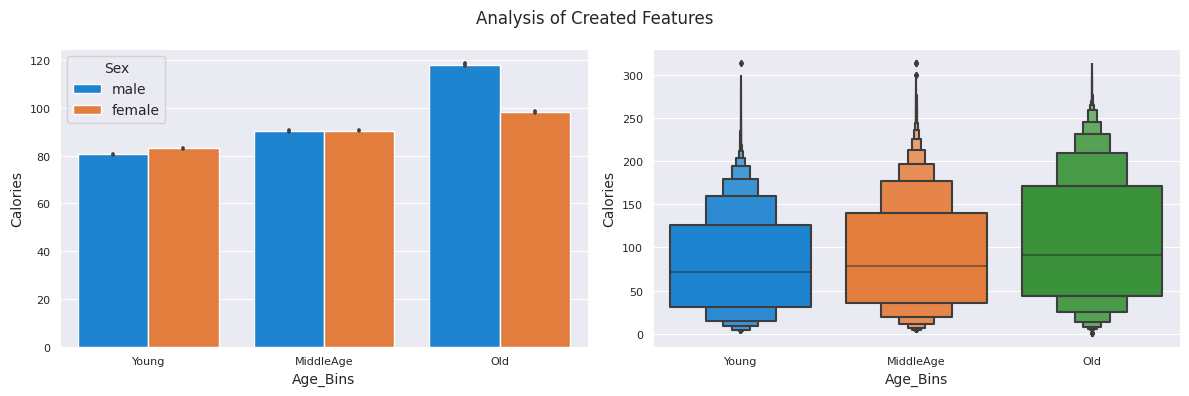

In [46]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

sns.barplot(data=calories_end, x="Age_Bins", y="Calories", hue="Sex", ax=axes[0])
sns.boxenplot(data=calories_end, x="Age_Bins", y="Calories", ax=axes[1])

plt.suptitle(t="Analysis of Created Features")
plt.tight_layout()
plt.show()

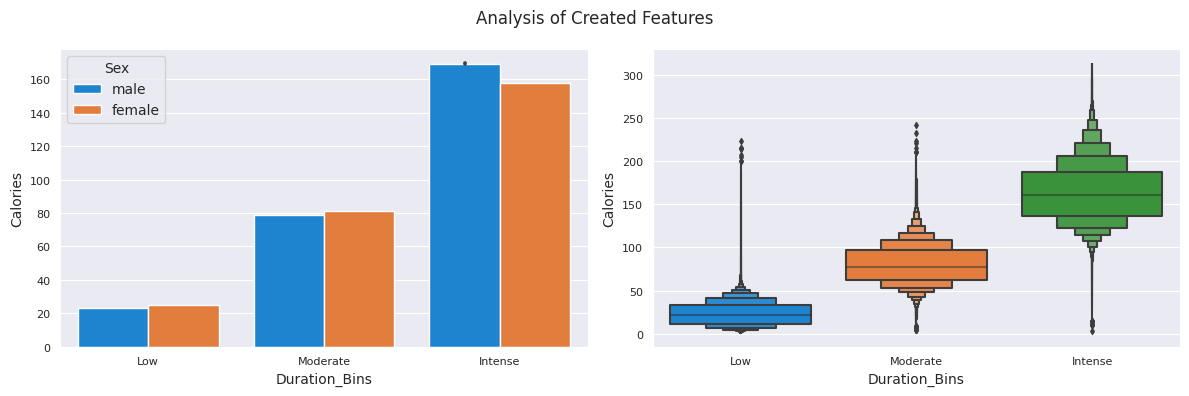

In [47]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

sns.barplot(data=calories_end, x="Duration_Bins", y="Calories", hue="Sex", ax=axes[0])
sns.boxenplot(data=calories_end, x="Duration_Bins", y="Calories", ax=axes[1])

plt.suptitle(t="Analysis of Created Features")
plt.tight_layout()
plt.show()

We can see that some outliers have been generated, we could test a larger number of bins in each feature, and see if we can avoid them.

## Encoding

We initially find one categorical variable to encode: 'Sex'. For this, we could use OneHotEncoder with the drop='if_binary' parameter. For the created variables, we could use OrdinalEncoder with the 'categories' parameter specified. We have three variables to encode. To avoid importing different methods and applying them and extending the code, we will map the three variables. However, I recommend trying the aforementioned encoding options and putting them into practice.

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html

In [48]:
# We create a useful function

def mapper(data, column, order):
    
    data[column] = data[column].map(order)
    data[column] = data[column].astype("float64")

    print(data[column].value_counts())

In [49]:
# We map the variables and change the format

sex_order = {"male" : 0, "female" : 1}
age_order = {"Young" : 0, "MiddleAge" : 1, "Old" : 2}
duration_order = {"Low" : 0, "Moderate" : 1, "Intense" : 2}

mapper(calories_end, "Sex", sex_order)
mapper(calories_end, "Age_Bins", age_order)
mapper(calories_end, "Duration_Bins", duration_order)

Sex
1.0    373807
0.0    372464
Name: count, dtype: int64
Age_Bins
0.0    386495
1.0    255700
2.0    104076
Name: count, dtype: int64
Duration_Bins
1.0    258162
0.0    247569
2.0    240540
Name: count, dtype: int64


In [50]:
calories_end.info()

<class 'pandas.core.frame.DataFrame'>
Index: 746271 entries, 0 to 749999
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Sex            746271 non-null  float64
 1   Age            746271 non-null  int64  
 2   Height         746271 non-null  float64
 3   Weight         746271 non-null  float64
 4   Duration       746271 non-null  float64
 5   Heart_Rate     746271 non-null  float64
 6   Body_Temp      746271 non-null  float64
 7   Calories       746271 non-null  float64
 8   Age_Bins       746271 non-null  float64
 9   Duration_Bins  746271 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 62.6 MB


We'll take this opportunity to perform a new correlation analysis. After scaling the data, we'll review the mutual importance.

<Axes: >

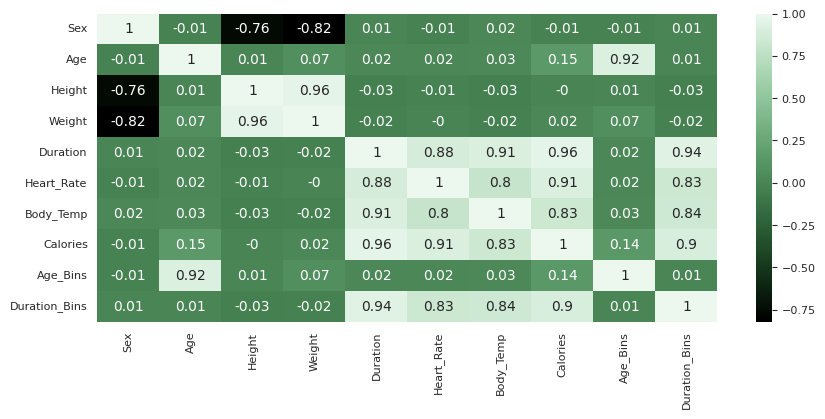

In [51]:
# We graph the correlation between the variables

matrix_calories = calories_end.corr(numeric_only=True).round(2)

plt.figure(figsize=(10, 4))

sns.heatmap(
    matrix_calories, 
    annot=True,
    cmap=sns.cubehelix_palette(
        start=2, rot=0, 
        dark=0, light=.95, 
        reverse=True, as_cmap=True
    ))

We can logically observe similarities in how the created variables are related, considering the original columns. We'll evaluate the variable selection later.

## Scaling

We will now proceed to perform a statistical analysis, and then evaluate the method we will use to scale the data where necessary.

In [52]:
calories_end.describe().T

,count,mean,std,min,25%,50%,75%,max
Sex,746271.0,0.500900,0.500000,0.0,0.0,1.0,1.0,1.0
Age,746271.0,41.424046,15.184260,20.0,28.0,40.0,52.0,79.0
Height,746271.0,174.830001,12.409243,155.0,164.0,174.0,185.0,200.0
Weight,746271.0,75.142439,13.944817,50.0,63.0,74.0,87.0,110.0
Duration,746271.0,15.441446,8.346877,1.0,8.0,15.0,23.0,30.0
Heart_Rate,746271.0,95.500278,9.372154,75.0,88.0,95.0,103.0,115.0
Body_Temp,746271.0,40.041293,0.758306,38.0,39.6,40.3,40.7,41.0
Calories,746271.0,88.405203,62.366861,1.0,34.0,77.0,136.0,314.0
Age_Bins,746271.0,0.621560,0.717040,0.0,0.0,0.0,1.0,2.0
Duration_Bins,746271.0,0.990581,0.808688,0.0,0.0,1.0,2.0,2.0


We proceed to scale the values of the initial numerical variables, which as we could analyze or logically deduce are on different scales. We will use StandardScaler, but I invite you to evaluate the different alternatives, always taking into account the data and its corresponding analysis.

https://scikit-learn.org/stable/modules/preprocessing.html

In [53]:
# We separate the target variable from the features

x_calories = calories_end.drop(columns="Calories")
y_calories = calories_end["Calories"]

In [54]:
# Numerical variables to scale

calories_numeric = x_calories[[
    "Age",
    "Height",
    "Weight",
    "Duration",
    "Heart_Rate",
    "Body_Temp"
]]

scaler = StandardScaler().set_output(transform="pandas")
scale_num = scaler.fit_transform(calories_numeric)

# We create a df with the remaining variables

calories_rest = x_calories[[
    "Sex",
    "Age_Bins",
    "Duration_Bins"
]]

# We concatenate the dataframes

x_end = pd.concat([calories_rest, scale_num], axis=1)

In [55]:
x_end.describe().T

,count,mean,std,min,25%,50%,75%,max
Sex,746271.0,5.008998e-01,0.500000,0.000000,0.000000,1.000000,1.000000,1.000000
Age_Bins,746271.0,6.215597e-01,0.717040,0.000000,0.000000,0.000000,1.000000,2.000000
Duration_Bins,746271.0,9.905812e-01,0.808688,0.000000,0.000000,1.000000,2.000000,2.000000
Age,746271.0,-1.960614e-16,1.000001,-1.410939,-0.884077,-0.093784,0.696508,2.474667
Height,746271.0,-3.666821e-16,1.000001,-1.598004,-0.872737,-0.066886,0.819551,2.028328
Weight,746271.0,3.918182e-16,1.000001,-1.802996,-0.870750,-0.081926,0.850321,2.499680
Duration,746271.0,1.034388e-16,1.000001,-1.730163,-0.891525,-0.052888,0.905555,1.744193
Heart_Rate,746271.0,7.027820e-16,1.000001,-2.187362,-0.800273,-0.053379,0.800214,2.080603
Body_Temp,746271.0,-3.872480e-16,1.000001,-2.691915,-0.581947,0.341164,0.868656,1.264275


## Feature Selection

Next, with the coded and scaled values, we will evaluate their mutual importance, in addition to a new correlation analysis. This allows us to make an initial assessment of variable selection.

In [56]:
x_end.corr()

,Sex,Age_Bins,Duration_Bins,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
Sex,1.000000,-0.009413,0.009769,-0.009318,-0.762433,-0.818399,0.009335,-0.008677,0.015326
Age_Bins,-0.009413,1.000000,0.010085,0.919983,0.011211,0.066684,0.016152,0.017643,0.028123
Duration_Bins,0.009769,0.010085,1.000000,0.009660,-0.026469,-0.018497,0.943106,0.826854,0.840816
Age,-0.009318,0.919983,0.009660,1.000000,0.011499,0.073145,0.015084,0.016138,0.027504
Height,-0.762433,0.011211,-0.026469,0.011499,1.000000,0.959454,-0.029715,-0.014014,-0.034123
Weight,-0.818399,0.066684,-0.018497,0.073145,0.959454,1.000000,-0.020446,-0.002931,-0.022854
Duration,0.009335,0.016152,0.943106,0.015084,-0.029715,-0.020446,1.000000,0.876712,0.908786
Heart_Rate,-0.008677,0.017643,0.826854,0.016138,-0.014014,-0.002931,0.876712,1.000000,0.801369
Body_Temp,0.015326,0.028123,0.840816,0.027504,-0.034123,-0.022854,0.908786,0.801369,1.000000


In [57]:
calories_scores = mutual_info_regression(x_end, y_calories)
calories_scores = pd.Series(calories_scores, name="Calories MI Scores", index=x_end.columns)
calories_scores = calories_scores.sort_values(ascending=False)
calories_scores

Duration         1.638192
Body_Temp        1.112687
Heart_Rate       0.972065
Duration_Bins    0.885721
Age              0.095845
Weight           0.052258
Height           0.048720
Age_Bins         0.032206
Sex              0.015901
Name: Calories MI Scores, dtype: float64

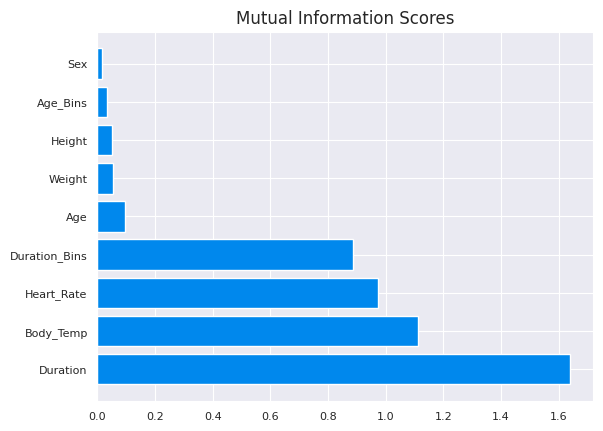

<Figure size 800x500 with 0 Axes>

In [58]:
scores = calories_scores.sort_values(ascending=True)
width = np.arange(len(calories_scores))
ticks = list(calories_scores.index)
plt.barh(width, calories_scores)
plt.yticks(width, ticks)
plt.title("Mutual Information Scores")
plt.figure(dpi=100, figsize=(8, 5))
plt.show()

Based on these results, as well as the different correlation analyses, we could drop some of the features. We will keep all the data for a first approach, and then we will return to this point. We will continue with the selection of models.

# Model Selection

We'll test three models, in addition to performing an initial optimization. We'll then use RMSLE (Root Mean Squared Logarithmic Error) to evaluate the results, being the evaluation metric of the competition, and choosing the model with the best initial performance.

Note: It should be remembered that the metric for this competition is RMSLE, this metric does not allow negative predictions. (ValueError: Mean Squared Logarithmic Error cannot be used when targets contain negative values)

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_log_error.html

In [59]:
# We separate the data into training and validation sets

x_train, x_val, y_train, y_val = (
    train_test_split(x_end, y_calories, test_size=0.2, random_state=42)
)

We will create a function for an initial evaluation of the models.

In [60]:
# Model eval function

def model_eval(model, model_name):

    y_pred = model.predict(x_val)
    y_pred_clip = np.clip(y_pred, a_min=0, a_max=np.inf)

    r2 = r2_score(y_val, y_pred_clip)

    rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred_clip))

    print(f"{model_name}\n\nR-squared score: {r2}\nRMSLE: {rmsle}")

## First model: LinearRegression

We'll start with a linear model. Here's the link to the documentation.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#

In [61]:
# We create the model instance

lr = LinearRegression()

# Train the model with the data

lr.fit(x_train, y_train)

LinearRegression()

In [62]:
# We evaluate the initial performance of the model

model_eval(lr, "LinearRegression")

LinearRegression

R-squared score: 0.9710558465829063
RMSLE: 0.5579198054619257


In [63]:
lr.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

We did not find good performance for the linear model. Furthermore, we can observe possible overfitting. We will evaluate the model using cross-validation. I perform a logarithmic transformation to avoid problems when using the cross-validation methods.

In [64]:
# Logarithmic transformation

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [65]:
# Evaluate the model using cross-validation

cv_scores_lr = cross_val_score(
    lr, x_train, y_train_log, 
    scoring="neg_mean_squared_log_error", 
    cv=5
)

print(f"Cross-validation scores: {cv_scores_lr}")
print(f"Mean CV scores: {np.mean(cv_scores_lr):.2f}")

Cross-validation scores: [-0.002202   -0.00222918 -0.00219046 -0.00226444 -0.00227958]
Mean CV scores: -0.00


We clearly have an overfitting problem. We'll continue with the next model.

## Second model: LGBMRegressor

The next model we will use is LightGBM (Light Gradient Boosting Machine). Is an open source, high-performance gradient boosting framework designed for efficient and scalable machine learning tasks.

https://lightgbm.readthedocs.io/en/latest/index.html

In [66]:
# We create the model instance

lgbr = LGBMRegressor(verbose=0)

# Train the model with the data

lgbr.fit(x_train, y_train)

LGBMRegressor(verbose=0)

In [67]:
# We evaluate the initial performance of the model

model_eval(lgbr, "LGBMRegressor")

LGBMRegressor

R-squared score: 0.9961829535606331
RMSLE: 0.070068622574637


In [68]:
lgbr.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': None,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'verbose': 0}

We achieved better results when analyzing the RMSLE; looking at the R-squared, we observed overfitting. We will evaluated using cross-validation.

In [69]:
# Evaluate the model using cross-validation

cv_scores_lgbr = cross_val_score(
    lgbr, x_train, y_train_log, 
    scoring="neg_mean_squared_log_error", 
    cv=5
)

print(f"Cross-validation scores lgbr: {cv_scores_lgbr}")
print(f"Mean CV scores lgbr: {np.mean(cv_scores_lgbr):.2f}")

Cross-validation scores lgbr: [-0.00031851 -0.00031598 -0.00030944 -0.0003111  -0.00031336]
Mean CV scores lgbr: -0.00


We're clearly experiencing an overfitting problem. Optimizing the models and re-processing the data is important, but we'll move on to the next model.

## Third model: CatBoostRegressor

Finally, we'll test CatBoostRegressor, a regression model that uses the Categorical Gradient Boosting (CatBoost) algorithm. It's a powerful tool for regression problems, especially when dealing with data with categorical features. Its approach to handling these features and its ability to avoid overfitting make it an attractive option for many machine learning problems.

https://catboost.ai/docs/en/concepts/python-reference_catboostregressor

In [70]:
# We create the model instance

cbr = CatBoostRegressor(silent=True)

# Train the model with the data

cbr.fit(x_train, y_train)

In [71]:
# We evaluate the initial performance of the model

model_eval(cbr, "CatBoostRegressor")

CatBoostRegressor

R-squared score: 0.9966530078293439
RMSLE: 0.06181689553900471


In [72]:
cbr.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'RMSE',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': True,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': False,
 'random_seed': 0,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'loss_function': 'RMSE',
 'lear

We found similar results to the previous model, we will continue evaluating with a cross-validation method.

In [73]:
# Evaluate the model using cross-validation

cv_scores_cbr = cross_val_score(
    cbr, x_train, y_train_log, 
    scoring="neg_mean_squared_log_error", 
    cv=5
)

print(f"Cross-validation scores lgbr: {cv_scores_cbr}")
print(f"Mean CV scores lgbr: {np.mean(cv_scores_cbr):.2f}")

Cross-validation scores lgbr: [-0.00030233 -0.00029559 -0.00029052 -0.00030051 -0.00029873]
Mean CV scores lgbr: -0.00


Again, we didn't find any major differences. As we mentioned earlier, model optimization, especially when we encounter overfitting, is a very important step.

We perform an initial test and model selection. We then select the model we consider to have the best initial performance and proceed to perform hyperparameter optimization, in addition to testing different cross-validation methods. I invite you to try a larger number of models and to perform different evaluations.

https://scikit-learn.org/stable/supervised_learning.html

# Modeling

After evaluating the models together, we proceed to select the one that gives us the best initial performance. Taking the initial results obtained, we will continue with CatBoostRegressor. We will try a different cross-validation method and use RandomizedSearchCV to optimize hyperparameters, and improve model performance.

In [74]:
# We establish the model to be optimized

final_cbr = CatBoostRegressor(silent=True)

In [75]:
# Create the KFold object

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [76]:
# We establish the parameters to test

cbr_param_grid = {
    "learning_rate" : [0.001, 0.01, 0.004],
    "max_depth" : [3, 4, 5],
    "l2_leaf_reg" : [1.0, 5.0, 0.5],
    "min_child_samples" : [1, 3, 6]
}

# We use random search to evaluate the grid

cbr_grid = RandomizedSearchCV(
    final_cbr,
    cbr_param_grid,
    cv=kfold,
    scoring="neg_mean_squared_log_error",
    return_train_score=True
)

cbr_search = cbr_grid.fit(x_train, y_train_log)

print(f"Parameters: {cbr_search.best_params_}\nScore: {cbr_search.best_score_}")

Parameters: {'min_child_samples': 6, 'max_depth': 5, 'learning_rate': 0.01, 'l2_leaf_reg': 5.0}
Score: -0.0003201262554954164


In [77]:
# We save the results within a dataframe

cbr_cv_results = pd.DataFrame(cbr_search.cv_results_)

cbr_cv_results.head().sort_values(by="rank_test_score", ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_min_child_samples,param_max_depth,param_learning_rate,param_l2_leaf_reg,params,split0_test_score,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
4,39.407569,2.305978,0.036605,0.005454,6,5,0.01,5.0,"{'min_child_samples': 6, 'max_depth': 5, 'lear...",-0.000338,...,-0.000319,-0.000318,-0.000319,-0.000316,-0.000318,-0.000319,-0.000317,-0.000319,-0.000318,0.000001
1,34.591115,0.525984,0.032275,0.001191,1,4,0.01,0.5,"{'min_child_samples': 1, 'max_depth': 4, 'lear...",-0.000351,...,-0.000331,-0.000330,-0.000330,-0.000329,-0.000329,-0.000330,-0.000329,-0.000331,-0.000330,0.000001
2,36.761288,0.858298,0.032784,0.002819,6,4,0.001,5.0,"{'min_child_samples': 6, 'max_depth': 4, 'lear...",-0.010727,...,-0.010533,-0.010541,-0.010539,-0.010539,-0.010524,-0.010531,-0.010534,-0.010527,-0.010533,0.000009
3,32.570623,0.657414,0.029720,0.002222,3,3,0.001,0.5,"{'min_child_samples': 3, 'max_depth': 3, 'lear...",-0.011605,...,-0.011386,-0.011390,-0.011391,-0.011398,-0.011372,-0.011383,-0.011388,-0.011379,-0.011385,0.000010
0,32.385632,0.432136,0.030378,0.001876,6,3,0.001,1.0,"{'min_child_samples': 6, 'max_depth': 3, 'lear...",-0.011605,...,-0.011386,-0.011390,-0.011392,-0.011397,-0.011372,-0.011383,-0.011389,-0.011380,-0.011385,0.000009


In [78]:
# We evaluate the performance of the model

y_pred_cbr_search_log = cbr_search.best_estimator_.predict(x_val)

y_pred_cbr_search = np.expm1(y_pred_cbr_search_log)

r2_cbr_search = r2_score(y_val, y_pred_cbr_search)

rmsle_cbr_search = np.sqrt(mean_squared_log_error(y_val, y_pred_cbr_search))

print(f"CatBoostRegressor optimization\n\nR-squared score: {r2_cbr_search}\nRMSE: {rmsle_cbr_search}")

CatBoostRegressor optimization

R-squared score: 0.9960509562016008
RMSE: 0.06265447759224513


After testing a different cross-validation method, in addition to an initial parameter grid, we were unable to optimize the model significantly. Possible overfitting can be assessed using the R-squared results. We stored the results in a data frame for future analysis, allowing us to continue optimizing our model with a broader grid.

We will define the final model, using the best performance model(CatBoostRegressor: default), train it with the data and make an evaluation of the final result. We will not be using the optimized model, since its performance is not good, as mentioned above, a more extensive optimization is required.

In [79]:
# We define the last model

#final_model = cbr_search.best_estimator_

final_model = cbr

final_model.get_params()

{'loss_function': 'RMSE', 'silent': True}

In [80]:
# We fit the best model

final_model.fit(x_train, y_train)

In [81]:
# We evaluate the final model performance

model_eval(final_model, "Final Model")

Final Model

R-squared score: 0.9966530078293439
RMSLE: 0.06181689553900471


After having defined our model, trained and evaluated its performance, we will proceed to evaluate the importance of the features. We will use the SHAP values method to determine the feature importance.

https://shap.readthedocs.io/en/latest/

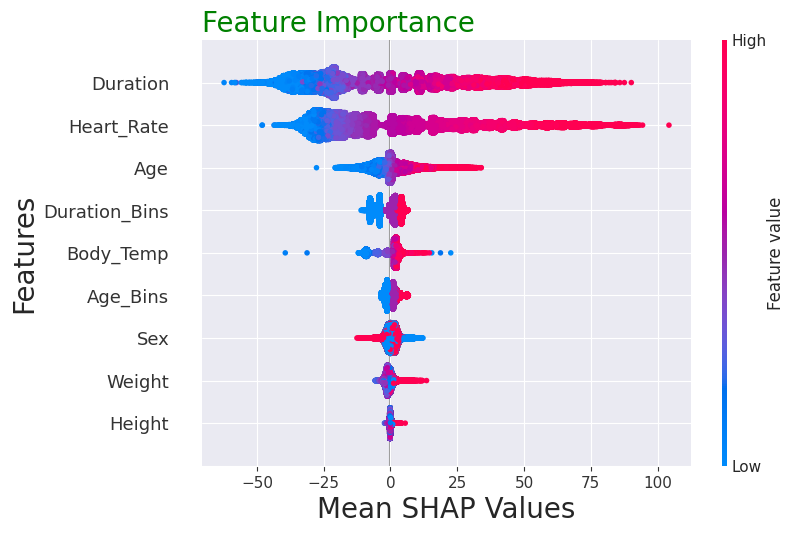

In [82]:
# We create an explainer for the best estimator

explainer = shap.Explainer(final_model)
shap_values = explainer.shap_values(x_val)

# we visualize the importance

fig = shap.summary_plot(
    shap_values,
    x_val,
    show=False
)
plt.title("Feature Importance", fontsize=20, color='g', loc='left')
plt.xlabel("Mean SHAP Values", fontsize=20)
plt.ylabel("Features", fontsize=20)
plt.show()

Each feature is assigned an importance value that represents its contribution to the model, how each feature affects each final prediction, the significance of each feature compared to others, and the model's reliance on the interaction between features, allowing us to evaluate the importance of each variable and a possible reduction of some. After evaluating the summary, we will continue with the test values to perform our first submission.

# Test data

We will start by loading the test data, and then proceed to apply the same treatment and cleaning where necessary.

In [83]:
# We load the test data and submission sample data

df_test = pd.read_csv("/kaggle/input/playground-series-s5e5/test.csv")

calories_sample = pd.read_csv("/kaggle/input/playground-series-s5e5/sample_submission.csv")

In [84]:
# We check the test data shape

print(f"Shape: {df_test.shape}")

Shape: (250000, 8)


In [85]:
df_test.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5


In [86]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
id,250000.0,874999.500000,72168.927986,750000.0,812499.75,874999.5,937499.25,999999.0
Age,250000.0,41.452464,15.177769,20.0,28.00,40.0,52.00,79.0
Height,250000.0,174.725624,12.822039,127.0,164.00,174.0,185.00,219.0
Weight,250000.0,75.147712,13.979513,39.0,63.00,74.0,87.00,126.0
Duration,250000.0,15.415428,8.349133,1.0,8.00,15.0,23.00,30.0
Heart_Rate,250000.0,95.479084,9.450161,67.0,88.00,95.0,103.00,128.0
Body_Temp,250000.0,40.036093,0.778448,37.1,39.60,40.3,40.60,41.5


In [87]:
df_test.describe(exclude = np.number)

,Sex
count,250000
unique,2
top,female
freq,125281


## Data wrangling & Preprocessing

In [88]:
# We check that no duplicate data is found

print(f"Length: {len(df_test.duplicated())}")

print(f"Duplicates: {df_test.duplicated().sum()}")

Length: 250000
Duplicates: 0


In [89]:
# We confirm that there is no null values

null_values_test = pd.DataFrame(
        {f"Null Data" : df_test.isnull().sum(), 
         "Percentage" : (df_test.isnull().sum()) / (len(df_test)) * (100)})

null_values_test

,Null Data,Percentage
id,0,0.0
Sex,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
Duration,0,0.0
Heart_Rate,0,0.0
Body_Temp,0,0.0


In [90]:
# We start by removing the variables that we will not use

test_new = df_test.drop(columns=["id"])

In [91]:
# We created the new features for test

test_new["Age_Bins"] = pd.cut(test_new["Age"], bins_age, labels=labels_age)
test_new["Duration_Bins"] = pd.cut(test_new["Duration"], bins_duration, labels=labels_duration)

In [92]:
# We map the variables and change the format

mapper(test_new, "Sex", sex_order)
mapper(test_new, "Age_Bins", age_order)
mapper(test_new, "Duration_Bins", duration_order)

Sex
1.0    125281
0.0    124719
Name: count, dtype: int64
Age_Bins
0.0    129119
1.0     85825
2.0     35056
Name: count, dtype: int64
Duration_Bins
1.0    86585
0.0    83152
2.0    80263
Name: count, dtype: int64


In [93]:
# Numerical variables to scale

test_numeric = test_new[[
    "Age",
    "Height",
    "Weight",
    "Duration",
    "Heart_Rate",
    "Body_Temp"
]]

test_scale_num = scaler.transform(test_numeric)

# We create a df with the remaining variables

test_rest = test_new[[
    "Sex",
    "Age_Bins",
    "Duration_Bins"
]]

# We concatenate the dataframes

test_end = pd.concat([test_rest, test_scale_num], axis=1)

In [94]:
test_end.describe()

,Sex,Age_Bins,Duration_Bins,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,0.501124,0.623748,0.988444,0.001872,-0.008411,0.000378,-0.003117,-0.002261,-0.006859
std,0.500000,0.717730,0.808411,0.999573,1.033266,1.002489,1.000271,1.008324,1.026562
min,0.000000,0.000000,0.000000,-1.410939,-3.854388,-2.591821,-1.730163,-3.040955,-3.878772
25%,0.000000,0.000000,0.000000,-0.884077,-0.872737,-0.870750,-0.891525,-0.800273,-0.581947
50%,1.000000,0.000000,1.000000,-0.093784,-0.066886,-0.081926,-0.052888,-0.053379,0.341164
75%,1.000000,1.000000,2.000000,0.696508,0.819551,0.850321,0.905555,0.800214,0.736783
max,1.000000,2.000000,2.000000,2.474667,3.559446,3.647061,1.744193,3.467692,1.923640


In [95]:
test_end.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Sex            250000 non-null  float64
 1   Age_Bins       250000 non-null  float64
 2   Duration_Bins  250000 non-null  float64
 3   Age            250000 non-null  float64
 4   Height         250000 non-null  float64
 5   Weight         250000 non-null  float64
 6   Duration       250000 non-null  float64
 7   Heart_Rate     250000 non-null  float64
 8   Body_Temp      250000 non-null  float64
dtypes: float64(9)
memory usage: 17.2 MB


We've finished loading and processing the test data, applying the same treatment. Next, we'll apply our model to predict our target variable and perform our first submission.

## Apply the Model & Submission File

In [96]:
# We apply the trained model

calories_pred = final_model.predict(test_end)
calories_predictions = np.clip(calories_pred, a_min=0, a_max=np.inf)

In [97]:
# We check that there are no negative values

print("Negative values in predictions:", (calories_predictions < 0).sum())

# We review the result

print("Total predictions: ", len(calories_predictions), "\n")

Negative values in predictions: 0
Total predictions:  250000 



In [98]:
# We create the dataframe

calories_submission = pd.DataFrame({
    "id" : df_test["id"], 
    "Calories" : calories_predictions
})

calories_submission["Calories"] = calories_submission["Calories"].round(decimals=3)

calories_submission.head()

,id,Calories
0,750000,27.466
1,750001,107.865
2,750002,87.585
3,750003,125.716
4,750004,76.028


In [99]:
# We compare the results with the sample

print(
    f"Shape Sample Submission: {calories_sample.shape}",
    f"\nShape Calories Submission: {calories_submission.shape}"
)
print("\n", calories_sample.head())

Shape Sample Submission: (250000, 2) 
Shape Calories Submission: (250000, 2)

        id  Calories
0  750000    88.283
1  750001    88.283
2  750002    88.283
3  750003    88.283
4  750004    88.283


In [100]:
# We convert the dataframe to a csv file

calories_submission.to_csv("submission.csv", index=False)

We've completed our first submission. Evaluating the results allows us to optimize and improve our model performance, returning to the various stages of data analysis, preparation, and processing.

# Final notes

Some useful notes to continue improving the initial results obtained:

- Extending feature engineering with transformations and feature relationships.
- Evaluate the importance of features to reduce non-contributing variables.
- Make a wider selection of models.
- Optimize the selected model further.
- Try an ensemble method, usually the most competitive approaches.